# A股 Level2 Market Microstructure Study
## Research Motivation

集合竞价不仅决定开盘价，也反映了开盘前市场参与者的信息、流动性和报价行为。本项目基于 A 股 Level2 数据，研究深交所股票在集合竞价阶段的价格发现过程。

## Research Questions

1. 集合竞价期间，价格是如何逐步形成开盘价的？
2. 不同股票之间的集合竞价行为是否存在差异？
3. 同一组股票在不同月份的集合竞价特征是否稳定？
4. 哪些微观结构特征可能对后续预测开盘价有帮助？

## Dataset

本项目主要使用 DolphinDB 中的 Level2 数据表，包括：

- `qtick`：盘口快照与价格/成交量信息
- `qorder`：逐笔委托数据
- `qknock`：逐笔成交数据

当前分析重点基于 `qtick`，并使用 `qorder` 辅助理解委托方向与买卖行为。

# 1. Understanding Level2 Data

## 1.1 Three Level2 Tables

本项目涉及三类 Level2 数据表：

| Table | Meaning | Role in This Project |
|---|---|---|
| qtick | 行情快照，包括盘口价格、成交量、累计成交额等 | 构建价格路径、波动率、成交量集中度等特征 |
| qorder | 逐笔委托，包括买卖方向、委托类型、提交/撤单行为 | 理解买卖压力与委托行为 |
| qknock | 逐笔成交 | 后续可用于更精确地研究成交结构 |

深交所开盘集合竞价主要发生在 09:15–09:25，并在 09:25 形成开盘价。09:25–09:30 期间市场进入开盘前过渡阶段。本文主要关注 09:15–09:30 这一窗口内的价格发现过程。

### Import Packages and DolphinDB Connection

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
from src.ddb_client import connect_ddb

s = connect_ddb()

df = s.run("""
select *
from loadTable("dfs://quota","qtick")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")


### Datetime Cleaning

In [3]:
raw = df.copy()

raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["time"] = pd.to_datetime(raw["time"], errors="coerce")

raw = raw.dropna(subset=["date", "time"])

# 用 date + time-of-day 重新合成真正的 datetime，避免 x 轴变成 1970
raw["datetime"] = raw.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

raw = raw.sort_values(["date", "datetime"]).reset_index(drop=True)

### Data Description

We use Level2 snapshot data (qtick), which contains:
- Best bid/ask prices (bp0/ap0)
- Trade price (new_price)
- Order book depth (bv0-av9)

We restrict analysis to the opening auction period (9:15–9:30).

In [4]:
# standardize time column to datetime and sort the dataframe by time
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# 9:15-9:30
df = df[
    (df["time"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["time"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

In [5]:
# clean invalid trades
df = df[df["new_price"] > 0].copy()

df = df.drop_duplicates(subset=["time", "new_price"])

### Market Variables

We construct three key variables:

- Mid Price: market expectation
- Trade Price: execution price
- Spread: liquidity tightness

In [6]:
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2
df["trade_price"] = df["new_price"]
df["spread"] = df["ap0"] - df["bp0"]

In [7]:
# microprice (IMPORTANT UPGRADE)
df["microprice"] = (
    df["bp0"] * df["av0"] + df["ap0"] * df["bv0"]
) / (df["bv0"] + df["av0"] + 1e-9)

# depth
df["bid_vol"] = df[[f"bv{i}" for i in range(10)]].sum(axis=1)
df["ask_vol"] = df[[f"av{i}" for i in range(10)]].sum(axis=1)

# imbalance (KEY VARIABLE)
df["imbalance"] = (df["bid_vol"] - df["ask_vol"]) / (df["bid_vol"] + df["ask_vol"] + 1e-9)

## 1.2 Timeline Chart 交易时间轴图

Hypothesis:
> During the opening auction, market prices converge from noisy quotes to a single clearing price at 9:25.

We test whether trade prices converge to mid-price and stabilize around auction time.

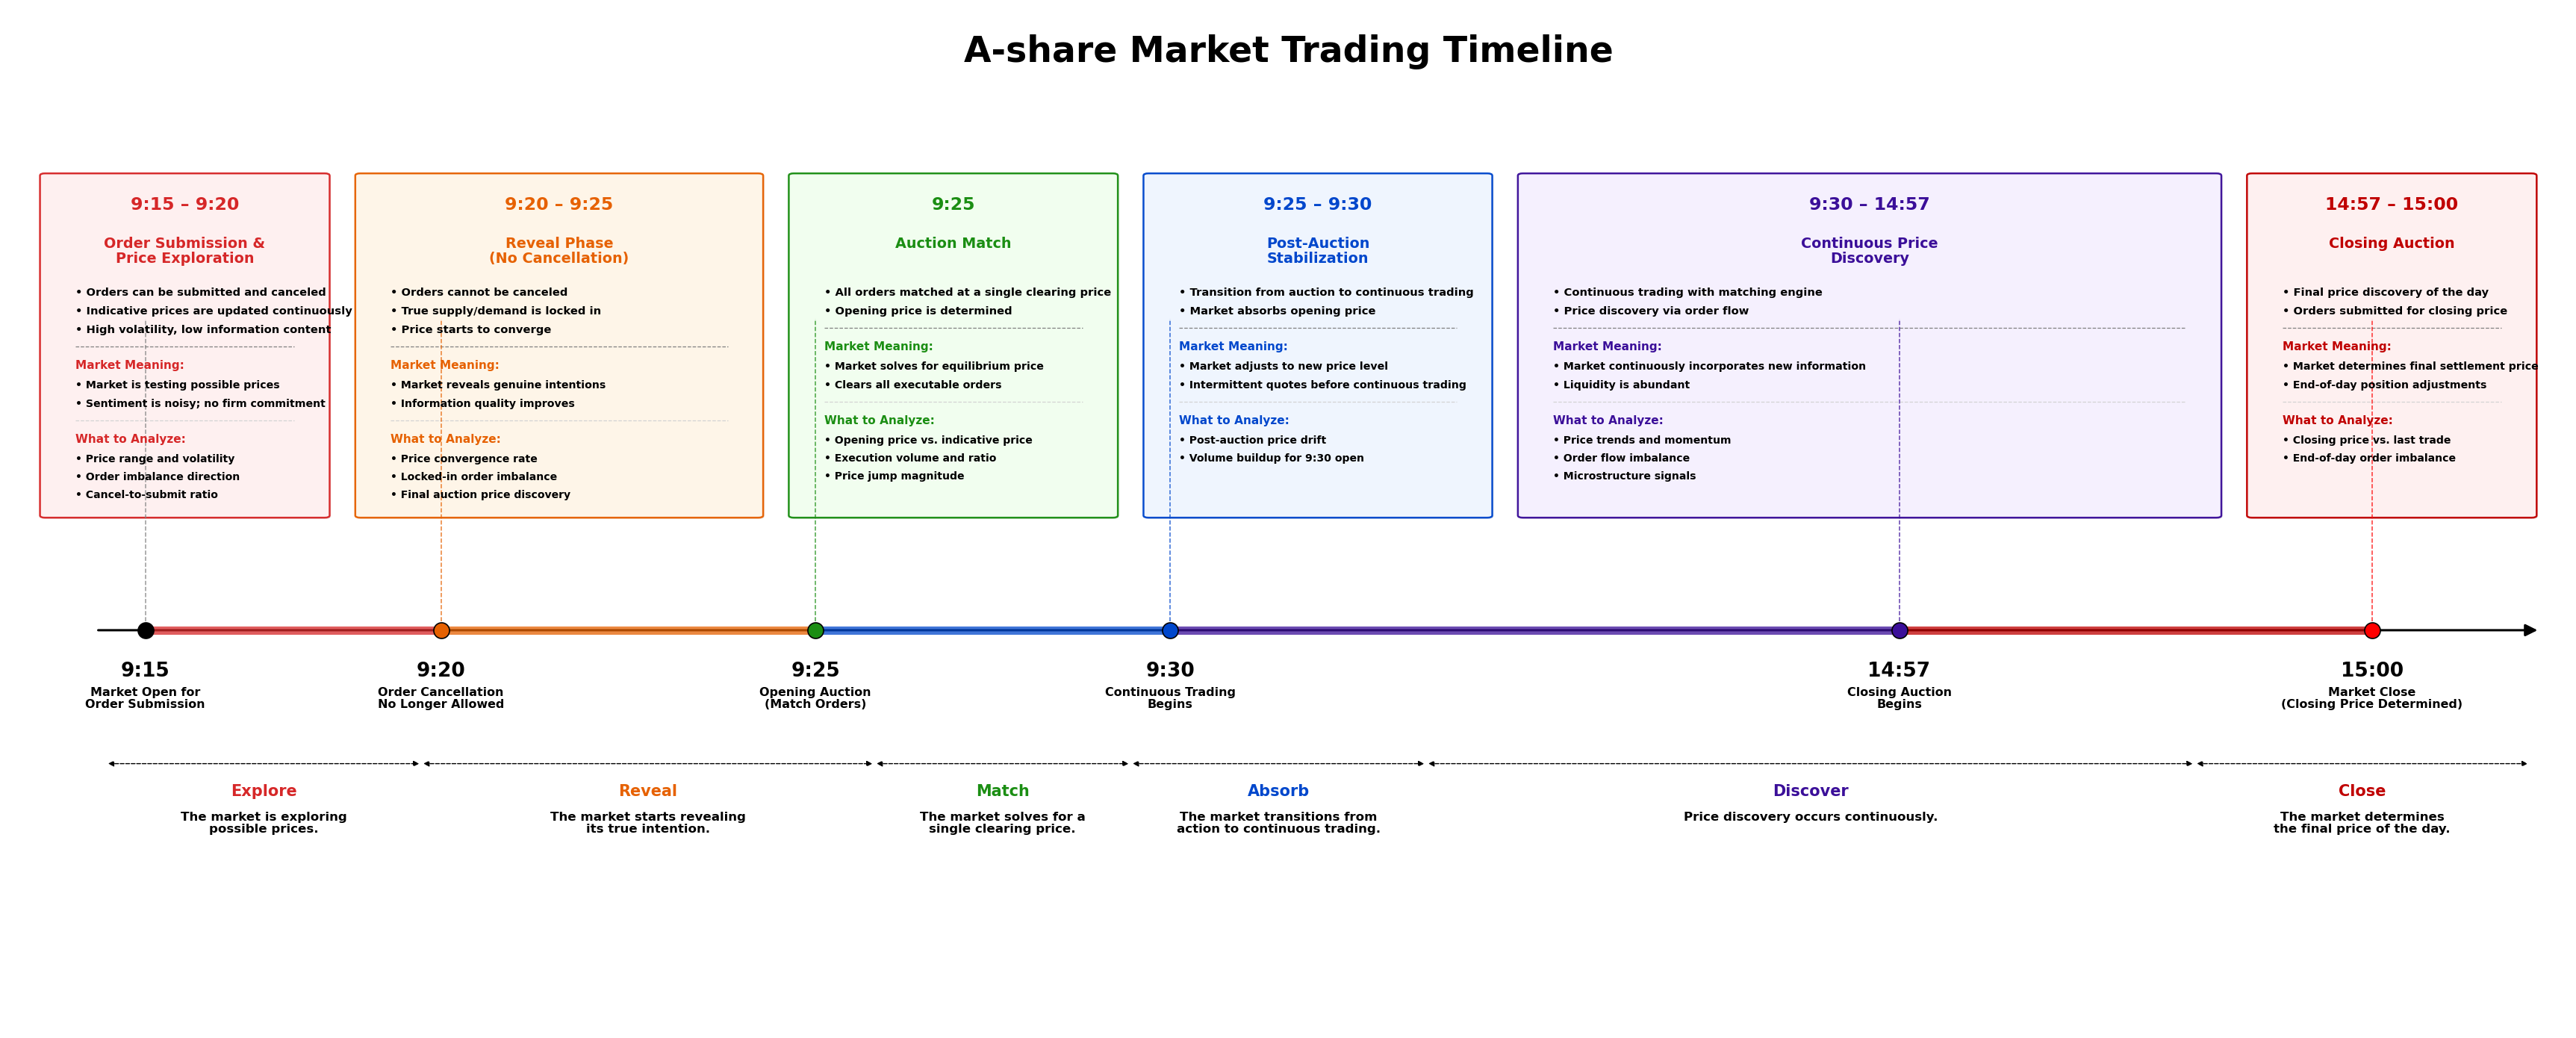

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

# ================== Y轴范围扩大 ==================
fig, ax = plt.subplots(figsize=(35, 14))
ax.set_xlim(0, 130)
ax.set_ylim(0, 115)  # 从100扩大到115，给底部更多空间
ax.axis("off")

# ---------- Title ----------
ax.text(
    65, 110,   # 从96下移到110
    "A-share Market Trading Timeline",
    ha="center", va="center",
    fontsize=34,  
    fontweight="bold"
)

# ---------- Colors ----------
colors = {
    "explore": "#d62728",
    "reveal": "#e66101",
    "match": "#1b8e13",
    "absorb": "#0047cc",
    "discover": "#3b0f99",
    "close": "#c00000",
}

light_colors = {
    "explore": "#fff1f1",
    "reveal": "#fff6e8",
    "match": "#f2fff0",
    "absorb": "#f0f6ff",
    "discover": "#f6f1ff",
    "close": "#fff1f1",
}

# ================== 时间轴整体下移 ==================
y_line = 45          # 时间轴（原来85 → 60，下移25）
card_y = 80          # 卡片到时间轴的连线终点
y_arrow = 30         # 底部功能描述（原来17 → 30）

# 卡片整体下移（原来 y 约 28，现在 +30）
card_base_y = 82     # 卡片底部Y坐标

def draw_card(card):
    # 卡片Y坐标整体下移30个单位
    x, y, w, h = card["x"], card["y"] + 30, card["w"], card["h"]
    key = card["key"]
    c = colors[key]

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.35,rounding_size=0.25",
        linewidth=1.8,
        edgecolor=c,
        facecolor=light_colors[key],
        alpha=0.97
    )
    box.set_path_effects([
        pe.SimplePatchShadow(offset=(1.2, -1.2), alpha=0.10),
        pe.Normal()
    ])
    ax.add_patch(box)

    cx = x + w / 2
    text_x = x + 1.45

    ax.text(cx, y + h - 2.2, card["time"],
            ha="center", va="top", fontsize=17,
            fontweight="bold", color=c)

    ax.text(cx, y + h - 6.8, card["title"],
            ha="center", va="top", fontsize=13.8,
            fontweight="bold", color=c, linespacing=1.05)

    yy = y + h - 12.5

    for b in card["bullets"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.6,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="gray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "Market Meaning:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["meaning"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.2,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="lightgray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "What to Analyze:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["analyze"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.1,
                fontweight="bold", color="black")
        yy -= 2.0

# ================== 卡片数据（Y坐标整体+30） ==================
cards = [
    {
        "x": 2, "y": 28, "w": 14, "h": 38,
        "key": "explore",
        "time": "9:15 – 9:20",
        "title": "Order Submission &\nPrice Exploration",
        "bullets": [
            "Orders can be submitted and canceled",
            "Indicative prices are updated continuously",
            "High volatility, low information content"
        ],
        "meaning": [
            "Market is testing possible prices",
            "Sentiment is noisy; no firm commitment"
        ],
        "analyze": [
            "Price range and volatility",
            "Order imbalance direction",
            "Cancel-to-submit ratio"
        ]
    },
    {
        "x": 18, "y": 28, "w": 20, "h": 38,
        "key": "reveal",
        "time": "9:20 – 9:25",
        "title": "Reveal Phase\n(No Cancellation)",
        "bullets": [
            "Orders cannot be canceled",
            "True supply/demand is locked in",
            "Price starts to converge"
        ],
        "meaning": [
            "Market reveals genuine intentions",
            "Information quality improves"
        ],
        "analyze": [
            "Price convergence rate",
            "Locked-in order imbalance",
            "Final auction price discovery"
        ]
    },
    {
        "x": 40, "y": 28, "w": 16, "h": 38,
        "key": "match",
        "time": "9:25",
        "title": "Auction Match",
        "bullets": [
            "All orders matched at a single clearing price",
            "Opening price is determined"
        ],
        "meaning": [
            "Market solves for equilibrium price",
            "Clears all executable orders"
        ],
        "analyze": [
            "Opening price vs. indicative price",
            "Execution volume and ratio",
            "Price jump magnitude"
        ]
    },
    {
        "x": 58, "y": 28, "w": 17, "h": 38,
        "key": "absorb",
        "time": "9:25 – 9:30",
        "title": "Post-Auction\nStabilization",
        "bullets": [
            "Transition from auction to continuous trading",
            "Market absorbs opening price"
        ],
        "meaning": [
            "Market adjusts to new price level",
            "Intermittent quotes before continuous trading"
        ],
        "analyze": [
            "Post-auction price drift",
            "Volume buildup for 9:30 open"
        ]
    },
    {
        "x": 77, "y": 28, "w": 35, "h": 38,
        "key": "discover",
        "time": "9:30 – 14:57",
        "title": "Continuous Price\nDiscovery",
        "bullets": [
            "Continuous trading with matching engine",
            "Price discovery via order flow"
        ],
        "meaning": [
            "Market continuously incorporates new information",
            "Liquidity is abundant"
        ],
        "analyze": [
            "Price trends and momentum",
            "Order flow imbalance",
            "Microstructure signals"
        ]
    },
    {
        "x": 114, "y": 28, "w": 14, "h": 38,
        "key": "close",
        "time": "14:57 – 15:00",
        "title": "Closing Auction",
        "bullets": [
            "Final price discovery of the day",
            "Orders submitted for closing price"
        ],
        "meaning": [
            "Market determines final settlement price",
            "End-of-day position adjustments"
        ],
        "analyze": [
            "Closing price vs. last trade",
            "End-of-day order imbalance"
        ]
    }
]

for card in cards:
    draw_card(card)

# ================== 节点 ==================
pos = {"9:15": 7, "9:20": 22, "9:25": 41, "9:30": 59, "14:57": 96, "15:00": 120}

node_info = [
    ("9:15", "black", "Market Open for\nOrder Submission"),
    ("9:20", colors["reveal"], "Order Cancellation\nNo Longer Allowed"),
    ("9:25", colors["match"], "Opening Auction\n(Match Orders)"),
    ("9:30", colors["absorb"], "Continuous Trading\nBegins"),
    ("14:57", colors["discover"], "Closing Auction\nBegins"),
    ("15:00", "red", "Market Close\n(Closing Price Determined)"),
]

for t, c, label in node_info:
    x = pos[t]

    ax.scatter(x, y_line, s=230, color=c, edgecolor="black", linewidth=1.2, zorder=5)

    ax.plot([x, x], [y_line + 1.0, card_y],
            linestyle="--", linewidth=1.1,
            color=c if c != "black" else "gray", alpha=0.8)

    ax.text(x, y_line - 3.5, t,
            ha="center", va="top", fontsize=19,  
            fontweight="bold", color="black")

    ax.text(x, y_line - 6.4, label,
            ha="center", va="top", fontsize=11.5, 
            fontweight="bold", color="black", linespacing=1.05)

# ================== Main timeline ==================
segments = [
    ("9:15", "9:20", "explore"),
    ("9:20", "9:25", "reveal"),
    ("9:25", "9:30", "absorb"),
    ("9:30", "14:57", "discover"),
    ("14:57", "15:00", "close"),
]

ax.add_patch(FancyArrowPatch(
    (pos["9:15"] - 2.5, y_line), (128.5, y_line),
    arrowstyle="-|>", mutation_scale=24,
    linewidth=2.2, color="black"
))

for start, end, key in segments:
    ax.plot(
        [pos[start], pos[end]],
        [y_line, y_line],
        color=colors[key],
        linewidth=8,
        solid_capstyle="round",
        alpha=0.75
    )

# ================== 底部功能区域 ==================
function_ranges = [
    (5, 21, "Explore", "The market is exploring\npossible prices.", "explore"),
    (21, 44, "Reveal", "The market starts revealing\nits true intention.", "reveal"),
    (44, 57, "Match", "The market solves for a\nsingle clearing price.", "match"),
    (57, 72, "Absorb", "The market transitions from\naction to continuous trading.", "absorb"),
    (72, 111, "Discover", "Price discovery occurs continuously.", "discover"),
    (111, 128, "Close", "The market determines\nthe final price of the day.", "close"),
]

for x1, x2, title, desc, key in function_ranges:
    ax.add_patch(FancyArrowPatch(
        (x1, y_arrow), (x2, y_arrow),
        arrowstyle="<|-|>",
        mutation_scale=11,
        linewidth=1.0,
        linestyle="--",
        color="black"
    ))

    ax.text((x1 + x2) / 2, y_arrow - 2.3, title,
            ha="center", va="top", fontsize=15, 
            fontweight="bold", color=colors[key])

    ax.text((x1 + x2) / 2, y_arrow - 5.4, desc,
            ha="center", va="top", fontsize=12, 
            fontweight="bold", color="black", linespacing=1.05)

plt.tight_layout()
plt.show()

| 时间段       | 含义              | 行为                 |
| --------- | --------------- | ------------------ |
| 9:15–9:20 | early auction   | 撤单+试探报价            |
| 9:20–9:25 | locked phase    | 不可撤单 + 意愿聚集        |
| 9:24–9:25 | pre-close build | order imbalance 形成 |
| 9:25      | match           | auction price 形成   |
| 9:25–9:30 | stabilization   | 撮合后微调              |

# 3. Exploratory Data Analysis

## 3.1 Single-Stocki Case Study

### 3.1.1 样例股票集合竞价价格变化图
通过000009.SZ 20260311-20260410为期一个月的qtick数据来看集合竞价价格变化图

In [9]:
auction = raw[
    (raw["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (raw["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# 数值字段清洗
price_cols = ["bp0", "ap0", "new_price", "pre_close", "open"]

for col in price_cols:
    if col in auction.columns:
        auction[col] = pd.to_numeric(auction[col], errors="coerce")

# qtick 盘口参考价格：不要依赖 new_price
auction["mid_price"] = (auction["bp0"] + auction["ap0"]) / 2
auction.loc[auction["mid_price"] <= 0, "mid_price"] = np.nan

# 有效成交价，仅用于散点
auction["trade_price"] = auction["new_price"]
auction.loc[auction["trade_price"] <= 0, "trade_price"] = np.nan

# 相对昨收涨跌幅
auction.loc[auction["pre_close"] <= 0, "pre_close"] = np.nan
auction["auction_ret"] = auction["mid_price"] / auction["pre_close"] - 1

print("Trading days:", auction["date"].nunique())
print("Rows:", len(auction))

Trading days: 22
Rows: 871


In [10]:
# 选有效 mid_price 最多的一天作为样例日
day_counts = auction.groupby("date")["mid_price"].count().sort_values(ascending=False)
example_day = day_counts.index[0]

one_day = auction[auction["date"] == example_day].copy()

print("Example day:", example_day.date())
print("Valid mid price ticks:", one_day["mid_price"].notna().sum())
print("Valid trade ticks:", one_day["trade_price"].notna().sum())

Example day: 2026-03-16
Valid mid price ticks: 65
Valid trade ticks: 2


#### 3.1.1.1 单日价格变化

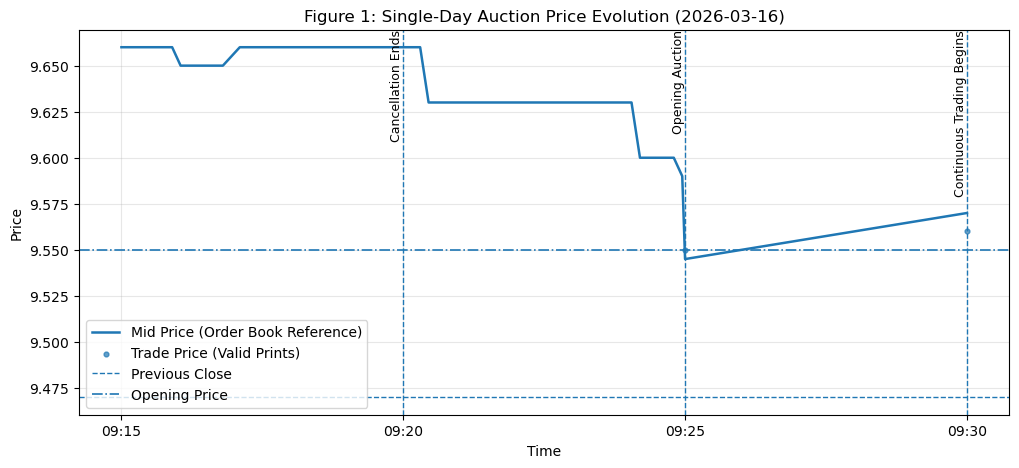

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day["datetime"],
    one_day["mid_price"],
    label="Mid Price (Order Book Reference)",
    linewidth=1.8
)

ax.scatter(
    one_day["datetime"],
    one_day["trade_price"],
    s=12,
    alpha=0.7,
    label="Trade Price (Valid Prints)"
)

# 昨收与开盘价
prev_close = one_day["pre_close"].dropna().iloc[0] if one_day["pre_close"].notna().any() else None
open_price = one_day["open"].dropna().iloc[-1] if "open" in one_day.columns and one_day["open"].notna().any() else None

if prev_close is not None:
    ax.axhline(prev_close, linestyle="--", linewidth=1, label="Previous Close")

if open_price is not None and open_price > 0:
    ax.axhline(open_price, linestyle="-.", linewidth=1.2, label="Opening Price")

# 关键时间节点
for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.Timestamp.combine(example_day.date(), pd.to_datetime(t).time())
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title(f"Figure 1: Single-Day Auction Price Evolution ({example_day.date()})")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

- 9：15-9：20：价格在9.65，9.66附近震荡，说明买卖双已经有共识，价格并没有乱跳
- 9：20-9：25：价格开始下降，从9.63到9.60到9.59，说明市场真是卖压出现，因为不能撤单
- 9：25时：价格突然掉到9.545，且opening price ≈ previous close，可暂时说明前面的盘口价格可能偏乐观，在真正order成交后, equilibrium price lower.

#### 3.1.1.2 一个月平均路径Average Price Path

In [12]:
# 把每天对齐到统一 10 秒时间网格
def align_one_day(g, freq="10s"):
    current_date = g["date"].iloc[0]
    
    start = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:15:00").time())
    end = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:30:00").time())
    grid = pd.date_range(start=start, end=end, freq=freq)
    
    temp = g.sort_values("datetime").set_index("datetime")
    
    aligned = temp[["auction_ret"]].reindex(grid, method="ffill")
    aligned["auction_ret"] = aligned["auction_ret"].bfill()
    
    aligned["date"] = current_date
    aligned["clock_time"] = aligned.index.strftime("%H:%M:%S")
    
    return aligned.reset_index(drop=True)

aligned_list = []

for d, g in auction.groupby("date"):
    if g["auction_ret"].notna().sum() >= 5:
        aligned_list.append(align_one_day(g, freq="10s"))

aligned = pd.concat(aligned_list, ignore_index=True)

ret_matrix = aligned.pivot(
    index="clock_time",
    columns="date",
    values="auction_ret"
).sort_index()

mean_path = ret_matrix.mean(axis=1)
std_path = ret_matrix.std(axis=1)

plot_times = pd.to_datetime(ret_matrix.index, format="%H:%M:%S")

print("Aligned days:", ret_matrix.shape[1])
print("Time points:", ret_matrix.shape[0])

Aligned days: 22
Time points: 91


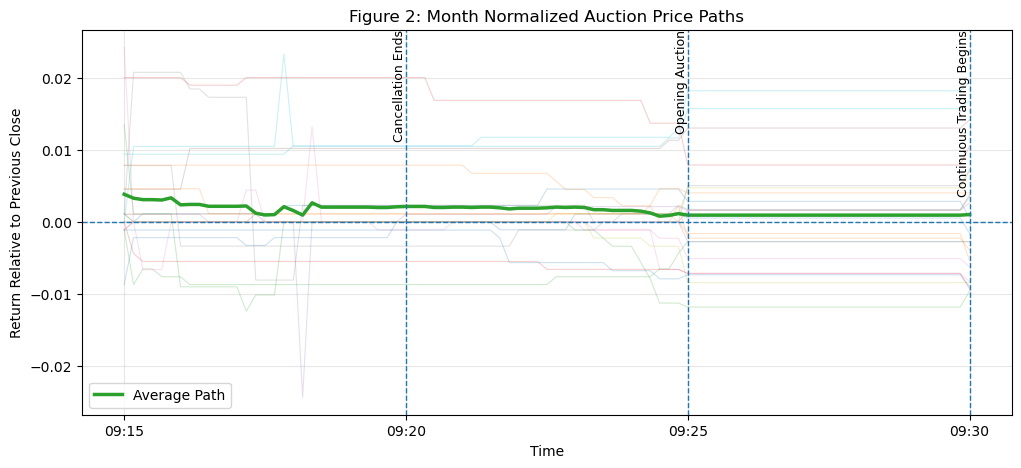

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

# 每天一条浅线
for col in ret_matrix.columns:
    ax.plot(
        plot_times,
        ret_matrix[col],
        alpha=0.22,
        linewidth=0.8
    )

# 平均路径
ax.plot(
    plot_times,
    mean_path,
    linewidth=2.5,
    label="Average Path"
)

ax.axhline(0, linestyle="--", linewidth=1)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 2: Month Normalized Auction Price Paths")
ax.set_xlabel("Time")
ax.set_ylabel("Return Relative to Previous Close")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这张表将一个月交易日的数据整合在一起并平均路径，发现仍是竞价初期偏乐观后市场逐渐修正，符合case抽样的价格变化趋势。

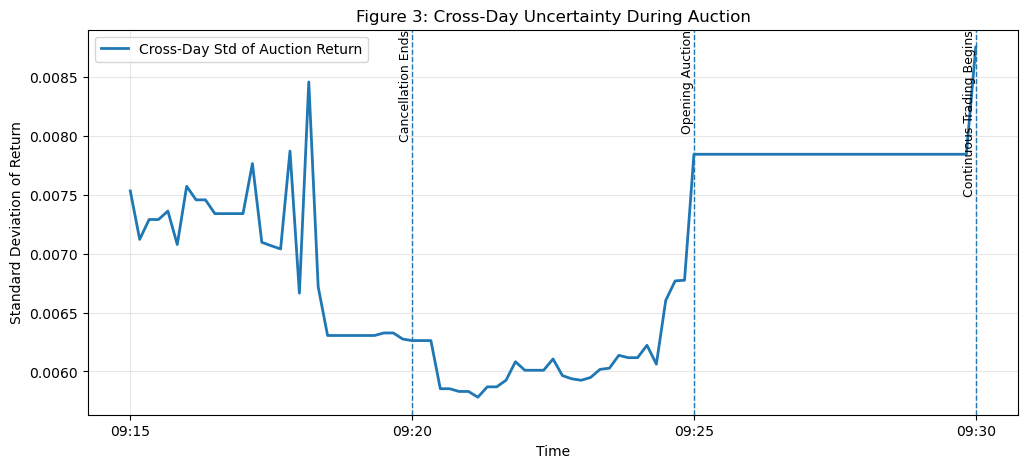

In [14]:
# 每个时刻的跨天标准差
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    std_path,
    linewidth=2,
    label="Cross-Day Std of Auction Return"
)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 3: Cross-Day Uncertainty During Auction")
ax.set_xlabel("Time")
ax.set_ylabel("Standard Deviation of Return")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

为了比较不同交易日集合竞价阶段价格信号的稳定程度，首先对所有交易日进行了时间对齐和价格标准化。
1. 价格标准化：对于每个交易日，定义 auction_return = mid_price/pre_close-1. 将盘口参考价格转换为相对昨收的涨跌幅，这样不同价格水平的股票可以放到同一尺度进行比较。
2. 时间对齐：由于qtick不是严格固定时间间隔产生，因此每天的快照时间点不同且有些时间点存在缺失。因此，我将所有交易日时间统一10s一取样
3. 计算标准差：通过计算standard deviation, 了解同一时刻，不同交易日之间价格信号的离散程度

第一阶段9：15-9：20：std比较高，再0.0072到0.0085附近摆动，说明不同交易日价格路径差距较大，市场预期尚未稳定，且价格信号具有较强noise
第二阶段9：20-9：25：std明显下降到0.0058附近，说明由于不能cancel order，市场价格开始收敛，不同交易日之间的价格分歧减弱且信息质量提高
第三阶段9：25后：std重新上升，可能原因有：开盘价存在跨日差异，高开于低开导致收益率std扩大，也有数据对齐方法带来的影响

### 3.1.2 委托量变化图
通过000009.SZ 20260311-20260410的qorder数据看委托量变化图

In [15]:
qorder = s.run("""
select *
from loadTable("dfs://quota","qorder")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")

In [16]:
# 1. Basic Cleaning

order = qorder.copy()

order["date"] = pd.to_datetime(order["date"], errors="coerce")
order["time"] = pd.to_datetime(order["time"], errors="coerce")

order = order.dropna(subset=["date", "time"])

order["datetime"] = order.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

order = order.sort_values(["date", "datetime"]).reset_index(drop=True)

# opening auction window
order = order[
    (order["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (order["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

order["order_volume"] = pd.to_numeric(order["order_volume"], errors="coerce").fillna(0)

# classify buy/sell
# 根据你打印结果：bs_flag = 1 是 buy, 2 是 sell
order["side"] = np.where(
    order["bs_flag"] == 1,
    "buy",
    np.where(order["bs_flag"] == 2, "sell", "unknown")
)

order = order[order["side"].isin(["buy", "sell"])].copy()

print("Trading days:", order["date"].nunique())
print("Rows:", len(order))
print(order["side"].value_counts())
print(order[["bs_flag", "side", "order_type"]].drop_duplicates())

Trading days: 22
Rows: 20839
side
sell    14130
buy      6709
Name: count, dtype: int64
   bs_flag  side  order_type
0        2  sell           0
2        1   buy           0


In [17]:
# 2. Aggregate to 10-second grid
order["clock_time"] = order["datetime"].dt.floor("10s").dt.strftime("%H:%M:%S")

agg = (
    order
    .groupby(["date", "clock_time", "side"])["order_volume"]
    .sum()
    .reset_index()
)

pivot = agg.pivot_table(
    index=["date", "clock_time"],
    columns="side",
    values="order_volume",
    fill_value=0
).reset_index()

if "buy" not in pivot.columns:
    pivot["buy"] = 0

if "sell" not in pivot.columns:
    pivot["sell"] = 0

pivot["total_order_volume"] = pivot["buy"] + pivot["sell"]

pivot["order_imbalance"] = np.where(
    pivot["total_order_volume"] > 0,
    (pivot["buy"] - pivot["sell"]) / pivot["total_order_volume"],
    np.nan
)

# average across all trading days
month_avg = (
    pivot
    .groupby("clock_time")[["buy", "sell", "total_order_volume", "order_imbalance"]]
    .mean()
    .reset_index()
)

plot_times = pd.to_datetime(month_avg["clock_time"], format="%H:%M:%S")

print("Valid clock points:", len(month_avg))

Valid clock points: 61


In [18]:
def add_auction_markers(ax):
    for t, label in [
        ("09:20:00", "Cancellation Ends"),
        ("09:25:00", "Opening Auction"),
        ("09:30:00", "Continuous Trading Begins")
    ]:
        x = pd.to_datetime(t, format="%H:%M:%S")
        ax.axvline(x, linestyle="--", linewidth=1)
        ax.text(
            x,
            ax.get_ylim()[1],
            label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=9
        )

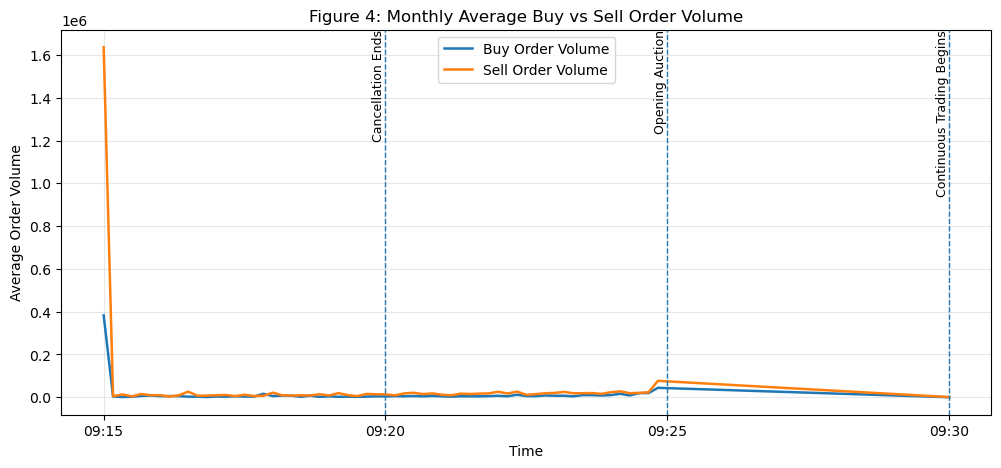

In [19]:
# Figure 4: Monthly Average Buy vs Sell Order Volume
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["buy"],
    label="Buy Order Volume",
    linewidth=1.8
)

ax.plot(
    plot_times,
    month_avg["sell"],
    label="Sell Order Volume",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 4: Monthly Average Buy vs Sell Order Volume")
ax.set_xlabel("Time")
ax.set_ylabel("Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

9：15：出现巨大峰值，可能因为集合竞价开始，大量隔夜订单进入，卖单一次性释放且整体股票偏空
9：15后：买卖量都很小，因为是逐笔委托，真正的新增订单没盘口那么连续
9：25-9：25：出现了第二次放量，说明临近开盘，投资者重新调整

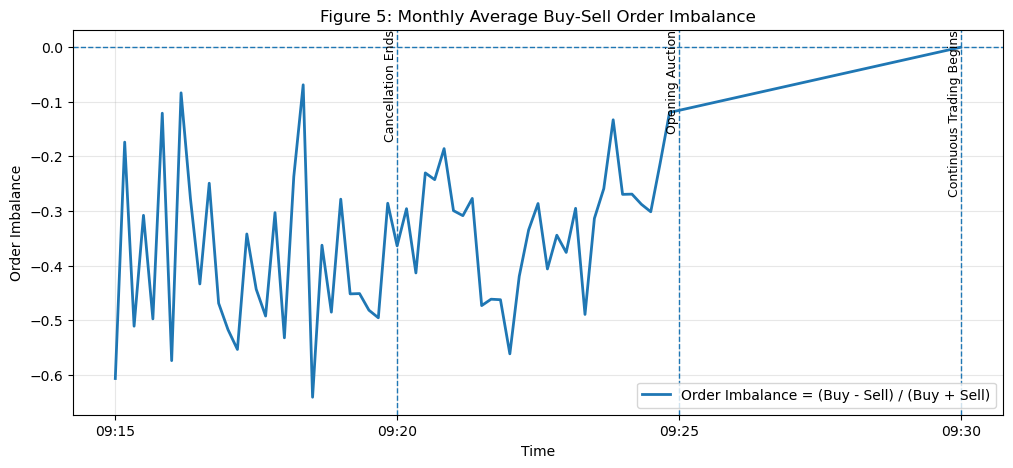

In [20]:
# Figure 5: Monthly Average Buy-Sell Order Imbalance

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["order_imbalance"],
    label="Order Imbalance = (Buy - Sell) / (Buy + Sell)",
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

add_auction_markers(ax)

ax.set_title("Figure 5: Monthly Average Buy-Sell Order Imbalance")
ax.set_xlabel("Time")
ax.set_ylabel("Order Imbalance")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

因为全部小于0，说明整个月卖方持续占优。且从9：15-9：20的-0.4到9：24的-0.1，这说明卖压在减弱，买卖开始趋于平衡，与qtick的验证匹配。

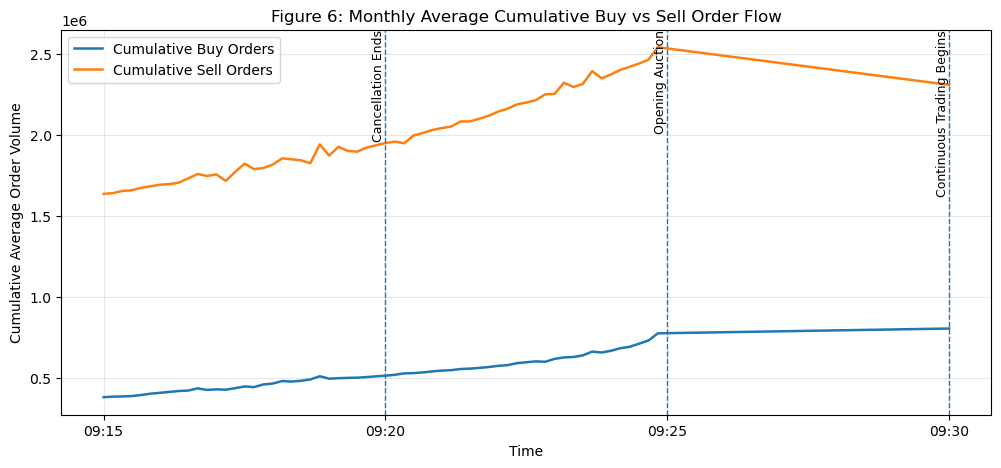

In [21]:
# Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow
pivot = pivot.sort_values(["date", "clock_time"]).copy()

pivot["cum_buy"] = pivot.groupby("date")["buy"].cumsum()
pivot["cum_sell"] = pivot.groupby("date")["sell"].cumsum()
pivot["cum_net"] = pivot["cum_buy"] - pivot["cum_sell"]

cum_avg = (
    pivot
    .groupby("clock_time")[["cum_buy", "cum_sell", "cum_net"]]
    .mean()
    .reset_index()
)

cum_times = pd.to_datetime(cum_avg["clock_time"], format="%H:%M:%S")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    cum_times,
    cum_avg["cum_buy"],
    label="Cumulative Buy Orders",
    linewidth=1.8
)

ax.plot(
    cum_times,
    cum_avg["cum_sell"],
    label="Cumulative Sell Orders",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这是累计的买卖单，说明整个竞价期间，卖方意愿要明显高于买方。9：25之前，卖单快速增加，这也说明了价格从9.66降到开盘价9.55原因。

Case study展示了一只股票的特征，但这些观察不足以让我们对市场有一定了解。所以，接下来我将基于多只股票分析。

Case study reveals the dynamics of one stock, but it remains unclear whether these observations generalize across the market. Therefore, we extend the analysis to multiple stocks.

## 3.2 Cross-Sectional Analysis: Multi-Stock Comparison

### 3.2.1 Auction Return Distribution

由于qtick在9：15-9：25提供信息的只有深交所的股票，这里先运用深交所的股票。

深交所内部大致可以这样分：
- 000 / 001 / 002 / 003 开头：深市主板 main_board
- 300 / 301 开头：创业板 chinext
- 200 开头：深市 B 股，一般先不要分析 exclude

eg. 000001.SZ 平安银行     深市主板
000858.SZ 五粮液       深市主板
002594.SZ 比亚迪       深市主板/原中小板
300750.SZ 宁德时代     创业板
300760.SZ 迈瑞医疗     创业板

In [22]:
import pandas as pd
from src.ddb_client import connect_ddb

s = connect_ddb()

In [23]:
sql = """
select distinct code
from loadTable("dfs://quota","qtick")
where date = 2026.03.11
"""

codes = s.run(sql)

codes.head()

,code
0,000001.SH
1,000015.SH
2,000017.SZ
3,000018.SH
4,000020.SZ


In [24]:
sz_codes = codes[
    codes["code"].str.endswith(".SZ")
].copy()

print(len(sz_codes))

22710


In [25]:
# 股票池如何
def board(code):

    if code.startswith(("000","001","002","003")):
        return "main"

    elif code.startswith(("300","301")):
        return "chinext"

    else:
        return "other"

sz_codes["board"] = sz_codes["code"].apply(board)

sz_codes["board"].value_counts()

board
other      19827
main        1491
chinext     1392
Name: count, dtype: int64

In [26]:
main_pool = sz_codes[sz_codes["board"] == "main"]
chinext_pool = sz_codes[sz_codes["board"] == "chinext"]

main_sample = main_pool.sample(
    n=min(30, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(20, len(chinext_pool)),
    random_state=42
)

stock_pool = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes = stock_pool["code"].tolist()

print("Selected stocks:", len(sample_codes))
print(stock_pool["board"].value_counts())
print(sample_codes[:10])

Selected stocks: 50
board
main       30
chinext    20
Name: count, dtype: int64
['000950.SZ', '000155.SZ', '002713.SZ', '000010.SZ', '002708.SZ', '002015.SZ', '002777.SZ', '001288.SZ', '002292.SZ', '002655.SZ']


In [27]:
codes_str = ",".join(
    [f'"{c}"' for c in sample_codes]
)

sql = f"""
select *
from loadTable("dfs://quota","qtick")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in ({codes_str})
  and time >= 09:15:00.000
  and time <= 09:30:00.000  
"""

qtick_50 = s.run(sql)

qtick_50.head()

,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,300768.SZ,2026-03-11,1970-01-01 09:15:00,0,0,18.55,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,300768.SZ,2026-03-11,1970-01-01 09:15:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,300768.SZ,2026-03-11,1970-01-01 09:16:12,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,300768.SZ,2026-03-11,1970-01-01 09:17:06,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,300768.SZ,2026-03-11,1970-01-01 09:18:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


In [28]:
qtick_50=qtick_50.merge(
    stock_pool[["code", "board"]],
    on="code",
    how="left"
)

In [29]:
qtick_50 = qtick_50.copy()

qtick_50["datetime"] = pd.to_datetime(
    qtick_50["date"].astype(str) + " " + qtick_50["time"].astype(str)
)

qtick_50 = qtick_50.sort_values(["code", "date", "datetime"])

C:\Users\work\AppData\Local\Temp\ipykernel_18132\2587534310.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qtick_50["datetime"] = pd.to_datetime(


In [30]:
qtick_50_filtered = qtick_50[qtick_50["new_price"] > 0].copy()

price_col = "new_price"
features = []

for (code, date), g in qtick_50_filtered.groupby(["code", "date"]):
    g = g.sort_values("time").copy()
    prices = g[price_col].dropna()
    
    if len(prices) < 2:
        continue

    first_price = prices.iloc[0]
    last_price = prices.iloc[-1]

    feature = {
        "code": code,
        "date": date,
        "n_ticks": len(g),
        "first_price": first_price,
        "last_price": last_price,
        "auction_return": (last_price - first_price) / first_price,
        "price_range": prices.max() - prices.min(),
        "price_volatility": prices.std(),
        "n_price_changes": prices.diff().ne(0).sum(),
        "max_price": prices.max(),
        "min_price": prices.min(),
    }

    if "volume" in g.columns:
        feature["total_volume"] = g["volume"].sum()

    if "amount" in g.columns:
        feature["total_amount"] = g["amount"].sum()

    features.append(feature)

feature_df = pd.DataFrame(features)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75


In [31]:
def classify_stock(code):
    if code.startswith(("000", "001", "002", "003")):
        return "main_board"
    elif code.startswith(("300", "301")):
        return "chinext"
    else:
        return "other"

feature_df["board"] = feature_df["code"].apply(classify_stock)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price,board
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33,main_board
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28,main_board
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10,main_board
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45,main_board
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75,main_board


In [32]:
summary = feature_df.groupby("board")[
    ["auction_return", "price_range", "price_volatility", "n_price_changes", "n_ticks"]
].describe()

summary

auction_return                                              \
                    count     mean       std       min       25%  50%   
board                                                                   
chinext             426.0  0.00070  0.006866 -0.033227 -0.000859  0.0   
main_board          658.0  0.00001  0.002997 -0.012903 -0.001300  0.0   

                               price_range            ... n_price_changes  \
                 75%       max       count      mean  ...             75%   
board                                                 ...                   
chinext     0.001894  0.085714       426.0  0.074765  ...             2.0   
main_board  0.001566  0.019791       658.0  0.038678  ...             2.0   

                n_ticks                                     
            max   count mean  std  min  25%  50%  75%  max  
board                                                       
chinext     2.0   426.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  
main_board  2.0   658.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  

[2 rows x 40 columns]

In [33]:
stock_summary = feature_df.groupby(["code", "board"]).agg(
    avg_return=("auction_return", "mean"),
    avg_abs_return=("auction_return", lambda x: x.abs().mean()),
    avg_range=("price_range", "mean"),
    avg_volatility=("price_volatility", "mean"),
    avg_price_changes=("n_price_changes", "mean"),
    avg_ticks=("n_ticks", "mean"),
    n_days=("date", "nunique")
).reset_index()

stock_summary = stock_summary.sort_values("avg_volatility", ascending=False)

stock_summary.head(20)

,code,board,avg_return,avg_abs_return,avg_range,avg_volatility,avg_price_changes,avg_ticks,n_days
46,301169.SZ,chinext,0.003499,0.006983,0.361364,0.255523,1.681818,2.0,22
28,002821.SZ,main_board,0.000367,0.001790,0.195000,0.137886,1.954545,2.0,22
12,001225.SZ,main_board,-0.000552,0.002671,0.131364,0.092888,1.818182,2.0,22
45,301080.SZ,chinext,-0.001239,0.002874,0.130000,0.091924,1.863636,2.0,22
43,300878.SZ,chinext,-0.000480,0.004612,0.130000,0.091924,1.666667,2.0,21
39,300606.SZ,chinext,-0.000089,0.003133,0.114091,0.080674,1.909091,2.0,22
49,301508.SZ,chinext,0.000433,0.003385,0.100909,0.071354,1.909091,2.0,22
48,301269.SZ,chinext,0.000351,0.001111,0.095000,0.067175,1.909091,2.0,22
41,300660.SZ,chinext,0.001449,0.001916,0.082273,0.058176,1.863636,2.0,22
44,300923.SZ,chinext,-0.000904,0.002896,0.079091,0.055926,1.909091,2.0,22


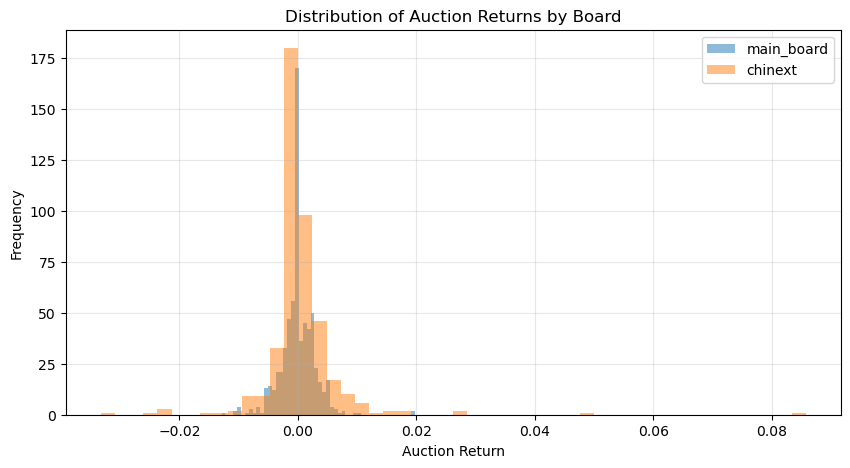

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for board in feature_df["board"].unique():
    data = feature_df.loc[feature_df["board"] == board, "auction_return"].dropna()
    plt.hist(data, bins=50, alpha=0.5, label=board)

plt.title("Distribution of Auction Returns by Board")
plt.xlabel("Auction Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

发现：创业板收益分布更分散，主板更集中。这意味着在集合竞价阶段，创业板的定价效率可能更低，提供了更大alpha挖掘空间，同时伴随更高风险

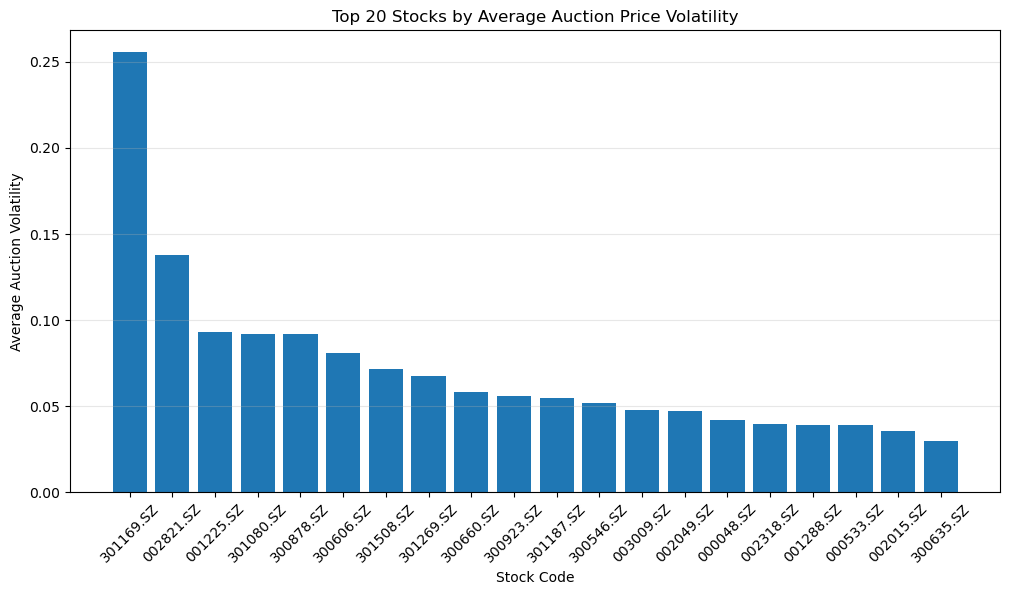

In [35]:
top20 = stock_summary.head(20).copy()

plt.figure(figsize=(12, 6))
plt.bar(top20["code"], top20["avg_volatility"])

plt.title("Top 20 Stocks by Average Auction Price Volatility")
plt.xlabel("Stock Code")
plt.ylabel("Average Auction Volatility")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### 3.2.2 Price Discovery Characteristics

In [36]:
corr_cols = [
    "auction_return",
    "price_range",
    "price_volatility",
    "n_price_changes",
    "n_ticks"
]

if "total_volume" in feature_df.columns:
    corr_cols.append("total_volume")

corr_matrix = feature_df[corr_cols].corr()

corr_matrix

,auction_return,price_range,price_volatility,n_price_changes,n_ticks
auction_return,1.000000,0.148759,0.148759,0.031553,NaN
price_range,0.148759,1.000000,1.000000,0.238438,NaN
price_volatility,0.148759,1.000000,1.000000,0.238438,NaN
n_price_changes,0.031553,0.238438,0.238438,1.000000,NaN
n_ticks,NaN,NaN,NaN,NaN,NaN


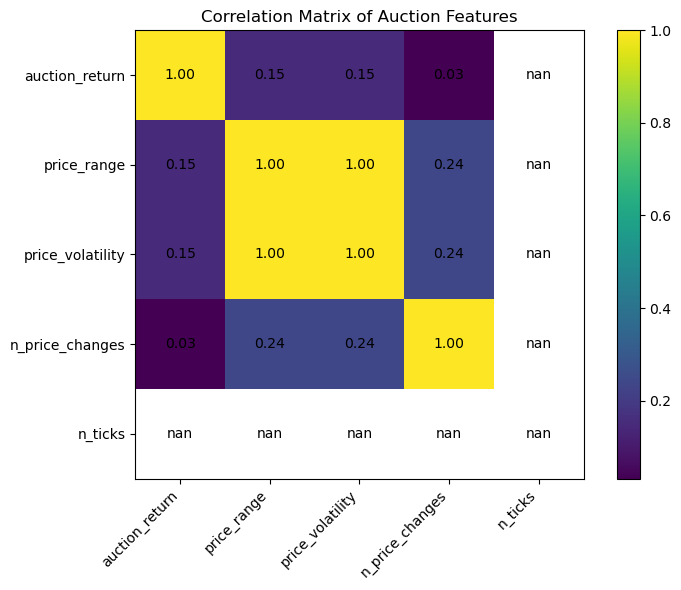

In [37]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation Matrix of Auction Features")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

价格区间（price_range）与价格波动率（price_volatility）完全相关（ρ = 1.00）
→ 两者度量同一维度，后续分析中可以选择其中一个使用，避免多重共线性。

价格变动次数（n_price_changes）与价格波动幅度呈弱正相关（ρ = 0.24）
→ 价格"动得多"不等于"动得大"，这两个指标提供了互补信息。

集合竞价收益率（auction_return）与所有波动类特征均无显著相关性（|ρ| ≤ 0.15）
→ 核心启示：集合竞价的方向（涨/跌）与价格发现的"激烈程度"是独立的市场信号。前者反映订单流的净方向，后者反映多空分歧程度。这一发现支持将"方向信号"和"分歧信号"作为两个独立的因子用于开盘策略构建。

n_ticks 因样本中所有交易日均为 2 个价格点而无法计算相关性
→ 当前数据粒度下，该指标不提供增量信息，建议在后续分析中排除

In [38]:
# =========================
# 1. Clean qtick_50
# =========================

df = qtick_50.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

df = df.dropna(subset=["date", "time"])

df["datetime"] = df.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

# auction window
df = df[
    (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# numeric columns
for col in ["bp0", "ap0", "new_price", "pre_close", "open", "volume", "amount"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# use order-book reference price, not only traded price
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2
df.loc[df["mid_price"] <= 0, "mid_price"] = np.nan

# fallback: if mid_price unavailable, use bp0
df["ref_price"] = df["mid_price"]
df.loc[df["ref_price"].isna(), "ref_price"] = df["bp0"]

df = df[df["ref_price"].notna()].copy()


# =========================
# 2. Trade volume increment
# =========================
# qtick volume is often cumulative, so use diff within each stock-day

if "volume" in df.columns:
    df["volume_diff"] = (
        df.groupby(["code", "date"])["volume"]
        .diff()
    )

    # first tick of the day: use current volume only if positive
    df["volume_diff"] = df["volume_diff"].fillna(df["volume"])

    # remove abnormal negative diff
    df.loc[df["volume_diff"] < 0, "volume_diff"] = 0
else:
    df["volume_diff"] = np.nan


# =========================
# 3. Feature function
# =========================

def count_turning_points(price_series):
    """
    Count how many times the price direction changes.
    Example: up -> down or down -> up.
    This captures intraday auction '波动次数 / 来回震荡次数'.
    """
    p = price_series.dropna()

    if len(p) < 3:
        return np.nan

    diff = p.diff().dropna()
    diff = diff[diff != 0]

    if len(diff) < 2:
        return 0

    direction = np.sign(diff)
    turns = (direction != direction.shift()).sum() - 1

    return max(turns, 0)


def classify_trend(ret, turns):
    """
    Label auction trend based on overall return and number of reversals.
    """
    if pd.isna(ret):
        return "unknown"

    if abs(ret) < 0.001:
        base = "flat"
    elif ret > 0:
        base = "up"
    else:
        base = "down"

    if pd.isna(turns):
        return base

    if turns >= 4:
        return base + "_volatile"
    elif turns >= 2:
        return base + "_with_reversal"
    else:
        return base + "_smooth"


features = []

for (code, date), g in df.groupby(["code", "date"]):
    g = g.sort_values("datetime").copy()
    p = g["ref_price"].dropna()

    if len(p) < 2:
        continue

    first_price = p.iloc[0]
    last_price = p.iloc[-1]
    max_price = p.max()
    min_price = p.min()

    auction_return = last_price / first_price - 1

    up_move = max_price / first_price - 1
    down_move = min_price / first_price - 1
    price_range_pct = (max_price - min_price) / first_price

    n_price_changes = p.diff().dropna().ne(0).sum()    
    n_turns = count_turning_points(p)

    # last minute: 09:29:00 - 09:30:00
    last_minute = g[
        (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
        (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ]

    total_vol = g["volume_diff"].sum()
    last_minute_vol = last_minute["volume_diff"].sum()

    last_minute_share = (
        last_minute_vol / total_vol
        if total_vol > 0
        else np.nan
    )

    feature = {
        "code": code,
        "date": date,
        "board": g["board"].iloc[0] if "board" in g.columns else None,

        "first_price": first_price,
        "last_price": last_price,
        "auction_return": auction_return,

        "up_move": up_move,
        "down_move": down_move,
        "price_range_pct": price_range_pct,

        "price_volatility": p.pct_change().std(),
        "n_price_changes": n_price_changes,
        "n_turns": n_turns,

        "total_volume": total_vol,
        "last_minute_volume": last_minute_vol,
        "last_minute_volume_share": last_minute_share,

        "n_ticks": len(g)
    }

    feature["trend_label"] = classify_trend(
        feature["auction_return"],
        feature["n_turns"]
    )

    features.append(feature)

feature_50 = pd.DataFrame(features)

feature_50.head()

C:\Users\work\AppData\Local\Temp\ipykernel_18132\2839814072.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  auction_return = last_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_18132\2839814072.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  up_move = max_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_18132\2839814072.py:130: RuntimeWarning: invalid value encountered in scalar divide
  down_move = min_price / first_price - 1
C:\Users\work\AppData\Local\Temp\ipykernel_18132\2839814072.py:131: RuntimeWarning: divide by zero encountered in scalar divide
  price_range_pct = (max_price - min_price) / first_price


,code,date,board,first_price,last_price,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,n_ticks,trend_label
0,000010.SZ,2026-03-11,main,4.36,4.345,-0.003440,0.002294,-0.016055,0.018349,0.002093,7,2,0.0,0.0,NaN,61,down_with_reversal
1,000010.SZ,2026-03-12,main,4.34,4.275,-0.014977,0.000000,-0.014977,0.014977,0.001244,5,0,0.0,0.0,NaN,33,down_smooth
2,000010.SZ,2026-03-13,main,4.53,4.130,-0.088300,0.000000,-0.103753,0.103753,0.013416,14,7,0.0,0.0,NaN,51,down_volatile
3,000010.SZ,2026-03-16,main,4.98,4.435,-0.109438,0.000000,-0.109438,0.109438,0.006958,15,2,0.0,0.0,NaN,70,down_with_reversal
4,000010.SZ,2026-03-17,main,4.65,4.775,0.026882,0.026882,0.000000,0.026882,0.002274,7,4,0.0,0.0,NaN,70,up_volatile


### 3.2.3 Price Formation Dynamics and Trending Activity

In [39]:
# 0. Copy data
# ============================================================

df = qtick_50.copy()


# ============================================================
# 1. Basic cleaning
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

df = df.dropna(subset=["date", "time"])

df["datetime"] = df.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

# auction window
df = df[
    (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# numeric columns
num_cols = [
    "bp0", "ap0", "new_price", "pre_close", "open",
    "new_volume", "sum_volume", "new_amount", "sum_amount",
    "new_bid_volume", "new_ask_volume"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# 2. Build valid reference price
# ============================================================

for col in ["bp0", "ap0", "new_price"]:
    if col in df.columns:
        df.loc[df[col] <= 0, col] = np.nan

# mid price only valid when both bid and ask exist
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2

# preferred price source:
# 1. mid_price
# 2. bp0
# 3. ap0
# 4. new_price
df["ref_price"] = (
    df["mid_price"]
    .fillna(df["bp0"])
    .fillna(df["ap0"])
    .fillna(df["new_price"])
)

df = df[df["ref_price"].notna()].copy()
df = df[df["ref_price"] > 0].copy()


# ============================================================
# 3. Volume cleaning
# ============================================================

for col in ["new_volume", "sum_volume", "new_bid_volume", "new_ask_volume"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df.loc[df[col] < 0, col] = 0
    else:
        df[col] = 0

# order-flow volume
df["new_orderflow_volume"] = df["new_bid_volume"] + df["new_ask_volume"]

df["tick_imbalance"] = np.where(
    df["new_orderflow_volume"] > 0,
    (df["new_bid_volume"] - df["new_ask_volume"]) / df["new_orderflow_volume"],
    np.nan
)


# ============================================================
# 4. Helper functions
# ============================================================

def count_turning_points(price_series):
    p = price_series.dropna()
    p = p[p > 0]

    if len(p) < 3:
        return np.nan

    diff = p.diff().dropna()
    diff = diff[diff != 0]

    if len(diff) < 2:
        return 0

    direction = np.sign(diff)
    turns = (direction != direction.shift()).sum() - 1

    return max(turns, 0)


def classify_trend(ret, turns):
    if pd.isna(ret):
        return "unknown"

    if abs(ret) < 0.001:
        base = "flat"
    elif ret > 0:
        base = "up"
    else:
        base = "down"

    if pd.isna(turns):
        return base

    if turns >= 4:
        return base + "_volatile"
    elif turns >= 2:
        return base + "_with_reversal"
    else:
        return base + "_smooth"


# ============================================================
# 5. Create stock-day features
# ============================================================

features = []

for (code, date), g in df.groupby(["code", "date"]):
    g = g.sort_values("datetime").copy()

    p = g["ref_price"].dropna()
    p = p[p > 0]

    if len(p) < 2:
        continue

    first_price = p.iloc[0]
    last_price = p.iloc[-1]
    max_price = p.max()
    min_price = p.min()

    if first_price <= 0:
        continue

    auction_return = last_price / first_price - 1
    up_move = max_price / first_price - 1
    down_move = min_price / first_price - 1
    price_range_pct = (max_price - min_price) / first_price

    n_price_changes = p.diff().dropna().ne(0).sum()
    n_turns = count_turning_points(p)

    last_minute = g[
        (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
        (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ].copy()

    # =========================
    # Volume features
    # =========================

    total_volume = g["new_volume"].sum()
    last_minute_volume = last_minute["new_volume"].sum()

    last_minute_volume_share = (
        last_minute_volume / total_volume
        if total_volume > 0
        else np.nan
    )

    max_sum_volume = g["sum_volume"].max()

    total_bid_volume = g["new_bid_volume"].sum()
    total_ask_volume = g["new_ask_volume"].sum()
    total_orderflow_volume = total_bid_volume + total_ask_volume

    orderflow_imbalance = (
        (total_bid_volume - total_ask_volume) / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    bid_volume_ratio = (
        total_bid_volume / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    ask_volume_ratio = (
        total_ask_volume / total_orderflow_volume
        if total_orderflow_volume > 0
        else np.nan
    )

    last_minute_bid_volume = last_minute["new_bid_volume"].sum()
    last_minute_ask_volume = last_minute["new_ask_volume"].sum()
    last_minute_orderflow = last_minute_bid_volume + last_minute_ask_volume

    last_minute_imbalance = (
        (last_minute_bid_volume - last_minute_ask_volume) / last_minute_orderflow
        if last_minute_orderflow > 0
        else np.nan
    )

    # =========================
    # Price-volume relation
    # =========================

    if total_volume > 0:
        volume_weighted_price = (
            (g["ref_price"] * g["new_volume"]).sum() / total_volume
        )
    else:
        volume_weighted_price = np.nan

    feature = {
        "code": code,
        "date": date,
        "board": g["board"].iloc[0] if "board" in g.columns else None,

        # price path
        "first_price": first_price,
        "last_price": last_price,
        "max_price": max_price,
        "min_price": min_price,

        "auction_return": auction_return,
        "up_move": up_move,
        "down_move": down_move,
        "price_range_pct": price_range_pct,
        "price_volatility": p.pct_change().std(),

        "n_price_changes": n_price_changes,
        "n_turns": n_turns,

        # volume
        "total_volume": total_volume,
        "max_sum_volume": max_sum_volume,
        "last_minute_volume": last_minute_volume,
        "last_minute_volume_share": last_minute_volume_share,

        # order flow
        "total_bid_volume": total_bid_volume,
        "total_ask_volume": total_ask_volume,
        "total_orderflow_volume": total_orderflow_volume,
        "bid_volume_ratio": bid_volume_ratio,
        "ask_volume_ratio": ask_volume_ratio,
        "orderflow_imbalance": orderflow_imbalance,

        # last minute order flow
        "last_minute_bid_volume": last_minute_bid_volume,
        "last_minute_ask_volume": last_minute_ask_volume,
        "last_minute_imbalance": last_minute_imbalance,

        # price-volume
        "volume_weighted_price": volume_weighted_price,

        # misc
        "n_ticks": len(g)
    }

    feature["trend_label"] = classify_trend(
        feature["auction_return"],
        feature["n_turns"]
    )

    features.append(feature)

feature_50 = pd.DataFrame(features)
feature_50 = feature_50.replace([np.inf, -np.inf], np.nan)

feature_50.nlargest(
    10,
    "auction_return"
)[[
    "code",
    "date",
    "auction_return"
]]

print("\nCore feature summary:")
display(
    feature_50[
        [
            "auction_return",
            "up_move",
            "down_move",
            "price_range_pct",
            "price_volatility",
            "n_price_changes",
            "n_turns",
            "total_volume",
            "last_minute_volume_share",
            "orderflow_imbalance",
            "last_minute_imbalance"
        ]
    ].describe()
)


Core feature summary:


,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume_share,orderflow_imbalance,last_minute_imbalance
count,1093.000000,1093.000000,1093.000000,1093.000000,1082.000000,1093.000000,1082.000000,1.093000e+03,1092.000000,0.0,0.0
mean,0.003391,0.015599,-0.016224,0.031824,0.005054,11.092406,4.323475,6.635465e+05,0.336597,NaN,NaN
std,0.032067,0.028566,0.027573,0.036331,0.007809,6.833959,3.361476,2.591205e+06,0.197601,NaN,NaN
min,-0.155996,0.000000,-0.219161,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN,NaN
25%,-0.008257,0.000000,-0.018527,0.010890,0.001604,6.000000,2.000000,2.700000e+04,0.186505,NaN,NaN
50%,0.000657,0.006119,-0.006865,0.019608,0.002858,10.000000,4.000000,8.804100e+04,0.314160,NaN,NaN
75%,0.010928,0.018225,0.000000,0.036488,0.005566,15.000000,6.000000,3.684350e+05,0.460520,NaN,NaN
max,0.300000,0.300000,0.000000,0.333333,0.125362,40.000000,20.000000,5.198899e+07,1.000000,NaN,NaN


In [40]:
feature_50_clean = feature_50.drop(
    columns=[
        "total_bid_volume",
        "total_ask_volume",
        "total_orderflow_volume",
        "bid_volume_ratio",
        "ask_volume_ratio",
        "orderflow_imbalance",
        "last_minute_bid_volume",
        "last_minute_ask_volume",
        "last_minute_imbalance"
    ],
    errors="ignore"
)

display(feature_50_clean.head())

print(feature_50_clean.shape)

display(
    feature_50_clean[
        [
            "auction_return",
            "up_move",
            "down_move",
            "price_range_pct",
            "price_volatility",
            "n_price_changes",
            "n_turns",
            "total_volume",
            "last_minute_volume",
            "last_minute_volume_share",
            "volume_weighted_price"
        ]
    ].describe()
)

,code,date,board,first_price,last_price,max_price,min_price,auction_return,up_move,down_move,...,price_volatility,n_price_changes,n_turns,total_volume,max_sum_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-03-11,main,4.36,4.345,4.370,4.290,-0.003440,0.002294,-0.016055,...,0.002093,7,2.0,768600,768600,15200,0.019776,4.340099,61,down_with_reversal
1,000010.SZ,2026-03-12,main,4.34,4.275,4.340,4.275,-0.014977,0.000000,-0.014977,...,0.001244,5,0.0,270500,270500,56500,0.208872,4.282911,33,down_smooth
2,000010.SZ,2026-03-13,main,4.53,4.130,4.530,4.060,-0.088300,0.000000,-0.103753,...,0.013416,14,7.0,316800,316800,196500,0.620265,4.116709,51,down_volatile
3,000010.SZ,2026-03-16,main,4.98,4.435,4.980,4.435,-0.109438,0.000000,-0.109438,...,0.006958,15,2.0,2906100,2906100,314500,0.108221,4.479589,70,down_with_reversal
4,000010.SZ,2026-03-17,main,4.65,4.775,4.775,4.650,0.026882,0.026882,0.000000,...,0.002274,7,4.0,2680200,2680200,467800,0.174539,4.758491,70,up_volatile


(1093, 21)


,auction_return,up_move,down_move,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price
count,1093.000000,1093.000000,1093.000000,1093.000000,1082.000000,1093.000000,1082.000000,1.093000e+03,1.093000e+03,1092.000000,1092.000000
mean,0.003391,0.015599,-0.016224,0.031824,0.005054,11.092406,4.323475,6.635465e+05,2.108175e+05,0.336597,23.195246
std,0.032067,0.028566,0.027573,0.036331,0.007809,6.833959,3.361476,2.591205e+06,1.036808e+06,0.197601,21.512179
min,-0.155996,0.000000,-0.219161,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.185000
25%,-0.008257,0.000000,-0.018527,0.010890,0.001604,6.000000,2.000000,2.700000e+04,7.000000e+03,0.186505,9.716571
50%,0.000657,0.006119,-0.006865,0.019608,0.002858,10.000000,4.000000,8.804100e+04,2.300000e+04,0.314160,16.539280
75%,0.010928,0.018225,0.000000,0.036488,0.005566,15.000000,6.000000,3.684350e+05,1.074000e+05,0.460520,28.556492
max,0.300000,0.300000,0.000000,0.333333,0.125362,40.000000,20.000000,5.198899e+07,2.561699e+07,1.000000,124.962778


In [41]:
stock_compare = (
    feature_50_clean
    .groupby(["code", "board"])
    .agg(
        n_days=("date", "nunique"),

        avg_return=("auction_return", "mean"),
        avg_abs_return=("auction_return", lambda x: x.abs().mean()),

        avg_up_move=("up_move", "mean"),
        avg_down_move=("down_move", "mean"),
        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),

        avg_price_changes=("n_price_changes", "mean"),
        avg_turns=("n_turns", "mean"),

        avg_total_volume=("total_volume", "mean"),
        avg_last_minute_volume=("last_minute_volume", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean"),

        avg_vwap=("volume_weighted_price", "mean")
    )
    .reset_index()
)

display(stock_compare.head())

,code,board,n_days,avg_return,avg_abs_return,avg_up_move,avg_down_move,avg_range_pct,avg_volatility,avg_price_changes,avg_turns,avg_total_volume,avg_last_minute_volume,avg_last_minute_share,avg_vwap
0,000010.SZ,main,22,0.000524,0.034804,0.020710,-0.020556,0.041266,0.005584,9.545455,4.409091,5.745182e+05,108504.545455,0.212028,4.232345
1,000048.SZ,main,22,0.002399,0.028046,0.033051,-0.032291,0.065342,0.008973,16.136364,6.363636,4.600023e+05,103904.545455,0.226342,19.629423
2,000155.SZ,main,22,-0.001298,0.029736,0.029001,-0.019751,0.048751,0.004625,17.727273,6.045455,1.341628e+06,252318.636364,0.185281,15.182929
3,000533.SZ,main,22,0.031271,0.055415,0.045977,-0.015548,0.061525,0.003753,15.954545,4.000000,3.432760e+06,725765.681818,0.219198,16.340207
4,000708.SZ,main,22,-0.004499,0.008461,0.004322,-0.009640,0.013962,0.002117,9.454545,4.136364,9.255705e+04,21058.636364,0.173454,16.571206


#### 上下幅度比较

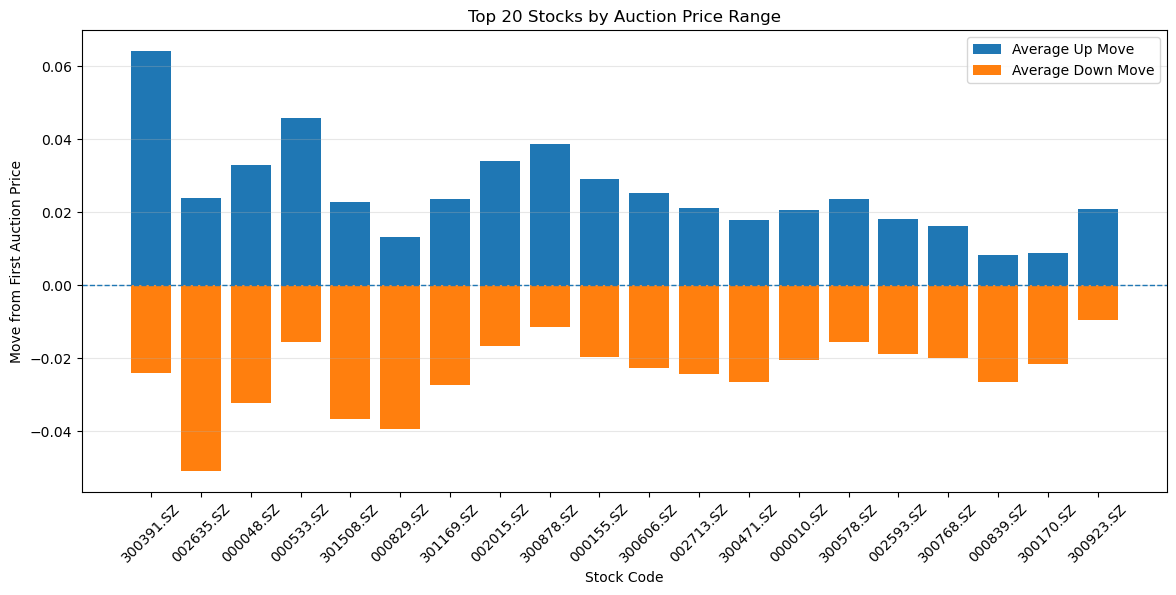

In [42]:
top20 = stock_compare.sort_values("avg_range_pct", ascending=False).head(20)

plt.figure(figsize=(14, 6))

plt.bar(top20["code"], top20["avg_up_move"], label="Average Up Move")
plt.bar(top20["code"], top20["avg_down_move"], label="Average Down Move")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Top 20 Stocks by Auction Price Range")
plt.xlabel("Stock Code")
plt.ylabel("Move from First Auction Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均向上波动（up_move）约为 1.56%
平均向下波动（down_move）约为 -1.62%
平均价格波动区间（price_range）约为 3.18%

不同股票之间存在明显差异，部分股票在集合竞价阶段价格波动幅度明显高于其他股票
集合竞价期间，大量买卖委托不断进入，系统不断重新计算虚拟成交价（Indicative Match Price）。价格不断上下调整，本质上是在寻找能够最大化成交量的均衡价格。因此，波动区间越大，说明市场买卖双方分歧越大；价格调整越剧烈，说明价格发现过程更加复杂；波动区间较小，则说明市场预期较一致，均衡价格能够较快形成。
价格波动区间可以作为衡量**集合竞价不确定性（Auction Uncertainty）**的重要指标

#### Price Reversals 波动次数比较

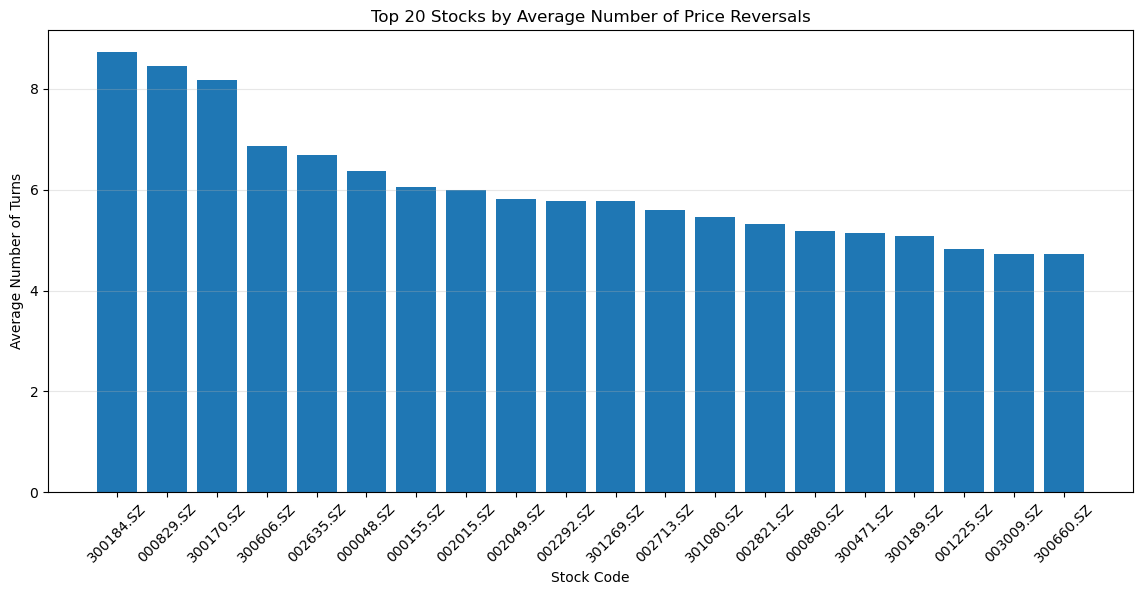

In [43]:
top20_turns = stock_compare.sort_values("avg_turns", ascending=False).head(20)

plt.figure(figsize=(14, 6))

plt.bar(top20_turns["code"], top20_turns["avg_turns"])

plt.title("Top 20 Stocks by Average Number of Price Reversals")
plt.xlabel("Stock Code")
plt.ylabel("Average Number of Turns")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均价格方向反转次数约为 4.3 次
部分股票平均反转次数超过 8 次

说明不同股票在集合竞价过程中存在明显不同的价格形成路径。因此，该指标能够反映：买卖双方是否持续博弈；市场是否不断修正对均衡价格的预期；价格形成过程是否稳定。相比普通波动率，价格反转次数更加关注价格形成路径（Price Formation Path），具有更强的微观结构含义。

#### last minute成交量

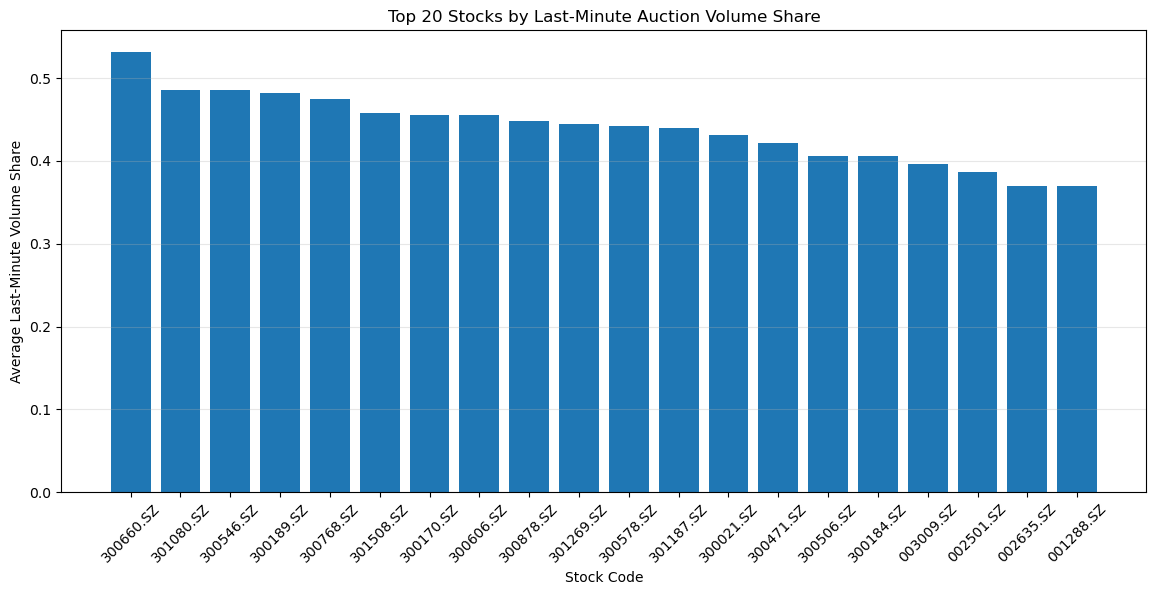

In [44]:
top20_last_min = (
    stock_compare
    .dropna(subset=["avg_last_minute_share"])
    .sort_values("avg_last_minute_share", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 6))

plt.bar(
    top20_last_min["code"],
    top20_last_min["avg_last_minute_share"]
)

plt.title("Top 20 Stocks by Last-Minute Auction Volume Share")
plt.xlabel("Stock Code")
plt.ylabel("Average Last-Minute Volume Share")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

统计结果显示：

平均约 33.7% 的成交量发生在集合竞价最后一分钟；
部分股票最后一分钟成交占比超过 50%。

说明大量成交集中发生在集合竞价结束前。随着集合竞价接近结束，投资者能够观察到更加稳定的虚拟成交价格，因此许多交易者会选择等待更多市场信息后，再于最后阶段提交委托。最后一分钟成交比例越高，说明：市场参与者倾向于延迟交易决策；大量订单集中于最后阶段进入市场；最终均衡价格主要在最后阶段完成，反映了信息到达速度以及交易的紧迫程度。

#### 趋势类型分布

In [45]:
trend_count = (
    feature_50
    .groupby(["board", "trend_label"])
    .size()
    .reset_index(name="count")
)

trend_count

,board,trend_label,count
0,chinext,down,4
1,chinext,down_smooth,52
2,chinext,down_volatile,79
3,chinext,down_with_reversal,48
4,chinext,flat,2
5,chinext,flat_smooth,2
6,chinext,flat_volatile,9
7,chinext,flat_with_reversal,5
8,chinext,up,2
9,chinext,up_smooth,39


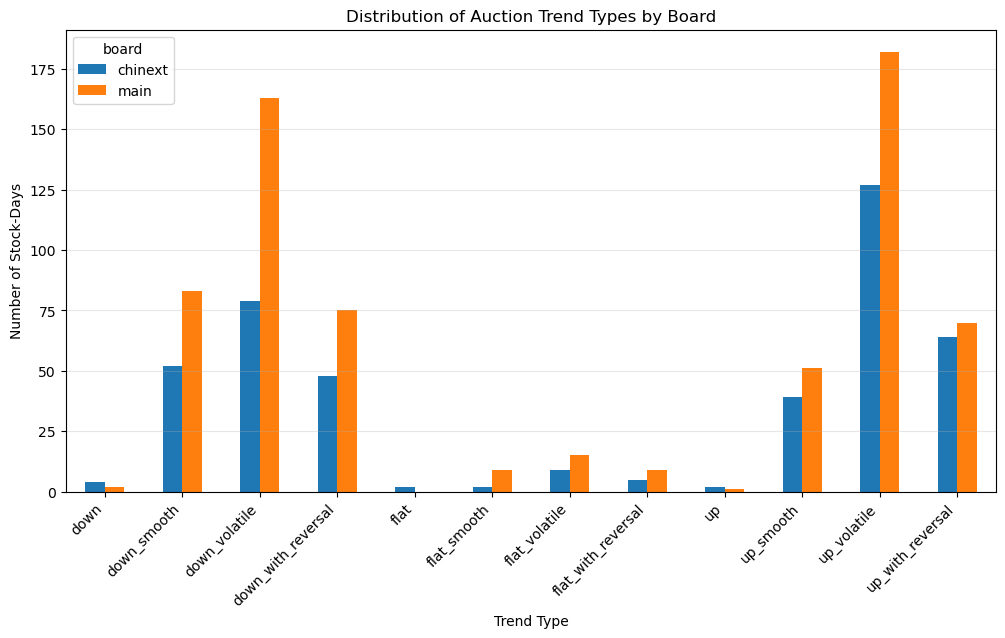

In [46]:
pivot_trend = trend_count.pivot(
    index="trend_label",
    columns="board",
    values="count"
).fillna(0)

pivot_trend.plot(kind="bar", figsize=(12, 6))

plt.title("Distribution of Auction Trend Types by Board")
plt.xlabel("Trend Type")
plt.ylabel("Number of Stock-Days")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

大多数股票属于：

up_volatile
down_volatile

说明集合竞价价格形成过程并不是简单的单边上涨或下跌，而是在不断调整中逐渐收敛至最终开盘价。市场不断吸收新增委托信息，价格持续修正，最终形成市场认可的均衡价格。

## 3.3 Longitudinal Analysis

#### 0. Select 15 stocks: 10 Main Board + 5 ChiNext

In [47]:
main_pool = sz_codes[sz_codes["board"] == "main"].copy()
chinext_pool = sz_codes[sz_codes["board"] == "chinext"].copy()

main_sample = main_pool.sample(
    n=min(10, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(5, len(chinext_pool)),
    random_state=42
)

stock_pool_15 = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes_15 = stock_pool_15["code"].tolist()

print("Selected stocks:", len(sample_codes_15))
display(stock_pool_15)

Selected stocks: 15


,code,board
0,000950.SZ,main
1,000155.SZ,main
2,002713.SZ,main
3,000010.SZ,main
4,002708.SZ,main
5,002015.SZ,main
6,002777.SZ,main
7,001288.SZ,main
8,002292.SZ,main
9,002655.SZ,main


#### 1. Query 3-month Qtick Data for Selected Stocks

In [48]:
# ============================================================
# 1. Query 3-month qtick data for 15 stocks
# ============================================================

start_date = "2026.02.01"
end_date = "2026.04.30"

codes_str = ",".join([f'"{c}"' for c in sample_codes_15])

sql_qtick_long = f"""
select *
from loadTable("dfs://quota","qtick")
where code in ({codes_str})
  and date >= {start_date}
  and date <= {end_date}
"""

qtick_long = s.run(sql_qtick_long)

print("qtick_long shape:", qtick_long.shape)
print("stocks:", qtick_long["code"].nunique())
print("dates:", qtick_long["date"].nunique())

display(qtick_long.head())


qtick_long shape: (3602207, 78)
stocks: 15
dates: 57


,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,002292.SZ,2026-02-02,1970-01-01 08:00:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,002292.SZ,2026-02-02,1970-01-01 08:16:36,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,002292.SZ,2026-02-02,1970-01-01 08:16:45,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,002292.SZ,2026-02-02,1970-01-01 09:15:00,0,0,9.26,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,002292.SZ,2026-02-02,1970-01-01 09:15:09,0,0,9.37,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


In [ ]:
qtick_long = qtick_long.merge(
    stock_pool_15[["code","board"]],
    on="code",
    how="left"
)

In [50]:
qtick_long["date"] = pd.to_datetime(qtick_long["date"], errors="coerce")

print("date min:", qtick_long["date"].min())
print("date max:", qtick_long["date"].max())

display(
    qtick_long
    .assign(month=qtick_long["date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(
        n_rows=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique")
    )
    .reset_index()
)

date min: 2026-02-02 00:00:00
date max: 2026-04-30 00:00:00


,month,n_rows,n_stocks,n_days
0,2026-02,888445,15,14
1,2026-03,1384854,15,22
2,2026-04,1328908,15,21


#### 2. Feature construction function


In [51]:
def build_auction_features(qtick_data):
    df = qtick_data.copy()

    # -------------------------
    # Basic cleaning
    # -------------------------
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

    df = df.dropna(subset=["date", "time"])

    df["datetime"] = df.apply(
        lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
        axis=1
    )

    df = df.sort_values(["code", "date", "datetime"]).reset_index(drop=True)

    # Opening call auction window
    df = df[
        (df["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
        (df["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
    ].copy()

    # -------------------------
    # Numeric columns
    # -------------------------
    num_cols = [
        "bp0", "ap0", "new_price", "pre_close", "open",
        "new_volume", "sum_volume", "new_amount", "sum_amount"
    ]

    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            df[col] = np.nan

    # -------------------------
    # Valid reference price
    # -------------------------
    for col in ["bp0", "ap0", "new_price"]:
        df.loc[df[col] <= 0, col] = np.nan

    df["mid_price"] = (df["bp0"] + df["ap0"]) / 2

    df["ref_price"] = (
        df["mid_price"]
        .fillna(df["bp0"])
        .fillna(df["ap0"])
        .fillna(df["new_price"])
    )

    df = df[df["ref_price"].notna()].copy()
    df = df[df["ref_price"] > 0].copy()

    # -------------------------
    # Volume cleaning
    # -------------------------
    for col in ["new_volume", "sum_volume", "new_amount", "sum_amount"]:
        df[col] = df[col].fillna(0)
        df.loc[df[col] < 0, col] = 0

    # -------------------------
    # Helper functions
    # -------------------------
    def count_turning_points(price_series):
        p = price_series.dropna()
        p = p[p > 0]

        if len(p) < 3:
            return np.nan

        diff = p.diff().dropna()
        diff = diff[diff != 0]

        if len(diff) < 2:
            return 0

        direction = np.sign(diff)
        turns = (direction != direction.shift()).sum() - 1

        return max(turns, 0)

    def classify_trend(ret, turns):
        if pd.isna(ret):
            return "unknown"

        if abs(ret) < 0.001:
            base = "flat"
        elif ret > 0:
            base = "up"
        else:
            base = "down"

        if pd.isna(turns):
            return base

        if turns >= 4:
            return base + "_volatile"
        elif turns >= 2:
            return base + "_with_reversal"
        else:
            return base + "_smooth"

    # -------------------------
    # Stock-day features
    # -------------------------
    features = []

    for (code, date), g in df.groupby(["code", "date"]):
        g = g.sort_values("datetime").copy()

        p = g["ref_price"].dropna()
        p = p[p > 0]

        if len(p) < 2:
            continue

        first_price = p.iloc[0]
        last_price = p.iloc[-1]
        max_price = p.max()
        min_price = p.min()

        if first_price <= 0:
            continue

        auction_return = last_price / first_price - 1
        up_move = max_price / first_price - 1
        down_move = min_price / first_price - 1
        price_range_pct = (max_price - min_price) / first_price

        n_price_changes = p.diff().dropna().ne(0).sum()
        n_turns = count_turning_points(p)

        last_minute = g[
            (g["datetime"].dt.time >= pd.to_datetime("09:29:00").time()) &
            (g["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
        ]

        total_volume = g["new_volume"].sum()
        last_minute_volume = last_minute["new_volume"].sum()

        last_minute_volume_share = (
            last_minute_volume / total_volume
            if total_volume > 0
            else np.nan
        )

        if total_volume > 0:
            volume_weighted_price = (
                (g["ref_price"] * g["new_volume"]).sum() / total_volume
            )
        else:
            volume_weighted_price = np.nan

        feature = {
            "code": code,
            "date": date,
            "month": pd.to_datetime(date).to_period("M").strftime("%Y-%m"),
            "board": g["board"].iloc[0] if "board" in g.columns else None,

            # price path
            "first_price": first_price,
            "last_price": last_price,
            "max_price": max_price,
            "min_price": min_price,

            "auction_return": auction_return,
            "up_move": up_move,
            "down_move": down_move,
            "price_range_pct": price_range_pct,
            "price_volatility": p.pct_change().std(),

            # path complexity
            "n_price_changes": n_price_changes,
            "n_turns": n_turns,

            # volume
            "total_volume": total_volume,
            "last_minute_volume": last_minute_volume,
            "last_minute_volume_share": last_minute_volume_share,

            # execution
            "volume_weighted_price": volume_weighted_price,

            # misc
            "n_ticks": len(g)
        }

        feature["trend_label"] = classify_trend(
            feature["auction_return"],
            feature["n_turns"]
        )

        features.append(feature)

    feature_df = pd.DataFrame(features)
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

    return feature_df

In [52]:
feature_long = build_auction_features(qtick_long)

print("feature_long shape:", feature_long.shape)
print("stocks:", feature_long["code"].nunique())
print("dates:", feature_long["date"].nunique())
print("months:", feature_long["month"].unique())

display(feature_long.head())

display(
    feature_long
    .groupby("month")
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique")
    )
    .reset_index()
)

feature_long shape: (854, 21)
stocks: 15
dates: 57
months: ['2026-02' '2026-03' '2026-04']


,code,date,month,board,first_price,last_price,max_price,min_price,auction_return,up_move,...,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-02-02,2026-02,main,3.39,3.405,3.420,3.39,0.004425,0.008850,...,0.008850,0.002343,3,1.0,97100,11200,0.115345,3.405000,18,up_smooth
1,000010.SZ,2026-02-03,2026-02,main,3.40,3.415,3.420,3.40,0.004412,0.005882,...,0.005882,0.001409,2,1.0,92900,1700,0.018299,3.415000,20,up_smooth
2,000010.SZ,2026-02-04,2026-02,main,3.51,3.525,3.525,3.46,0.004274,0.004274,...,0.018519,0.003629,7,2.0,321000,23300,0.072586,3.525000,24,up_with_reversal
3,000010.SZ,2026-02-05,2026-02,main,3.58,3.575,3.580,3.57,-0.001397,0.000000,...,0.002793,0.000777,2,1.0,47900,19000,0.396660,3.571983,18,down_smooth
4,000010.SZ,2026-02-06,2026-02,main,3.73,3.770,3.785,3.71,0.010724,0.014745,...,0.020107,0.002951,8,5.0,1176000,496000,0.421769,3.778673,46,up_volatile


,month,n_stock_days,n_stocks,n_days
0,2026-02,210,15,14
1,2026-03,330,15,22
2,2026-04,314,15,21


### 3.3.1 Monthly Evolution of Auction Characteristics

In [53]:
monthly_summary = (
    feature_long
    .groupby("month")
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique"),

        avg_return=("auction_return", "mean"),
        avg_abs_return=("auction_return", lambda x: x.abs().mean()),

        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),
        avg_turns=("n_turns", "mean"),
        avg_price_changes=("n_price_changes", "mean"),

        avg_total_volume=("total_volume", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean")
    )
    .reset_index()
)

display(monthly_summary)

,month,n_stock_days,n_stocks,n_days,avg_return,avg_abs_return,avg_range_pct,avg_volatility,avg_turns,avg_price_changes,avg_total_volume,avg_last_minute_share
0,2026-02,210,15,14,-0.003779,0.016332,0.023518,0.003045,3.695238,10.280952,501683.438095,0.326594
1,2026-03,330,15,22,-0.001185,0.017200,0.027832,0.003809,4.409231,11.436364,704995.609091,0.330183
2,2026-04,314,15,21,-0.002868,0.016979,0.028565,0.004072,4.375000,11.464968,790519.621019,0.327896


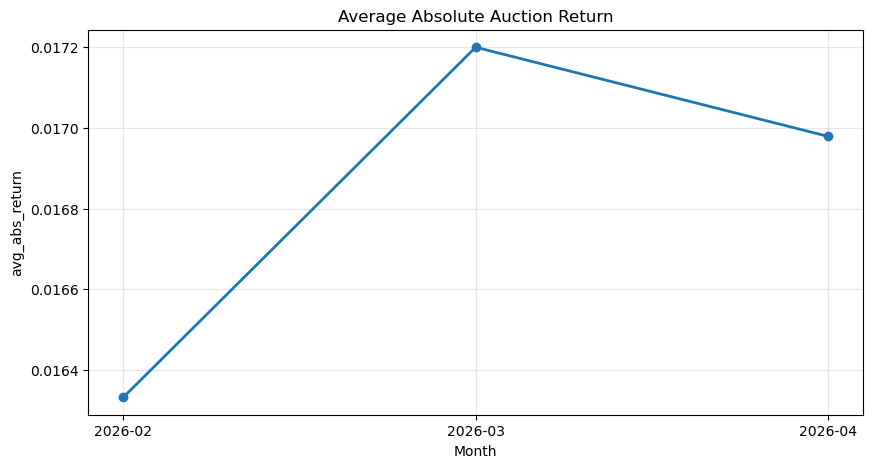

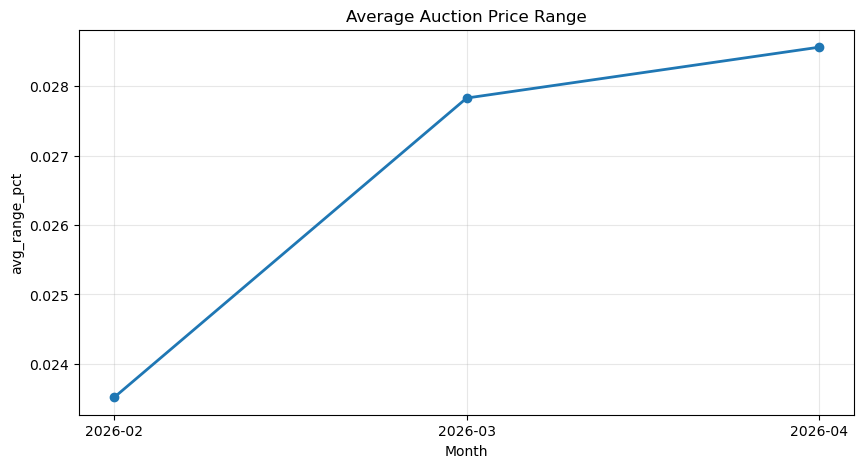

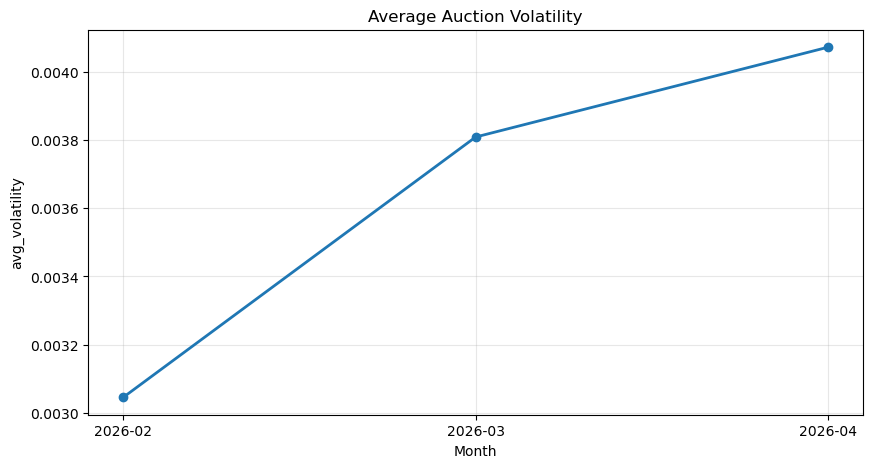

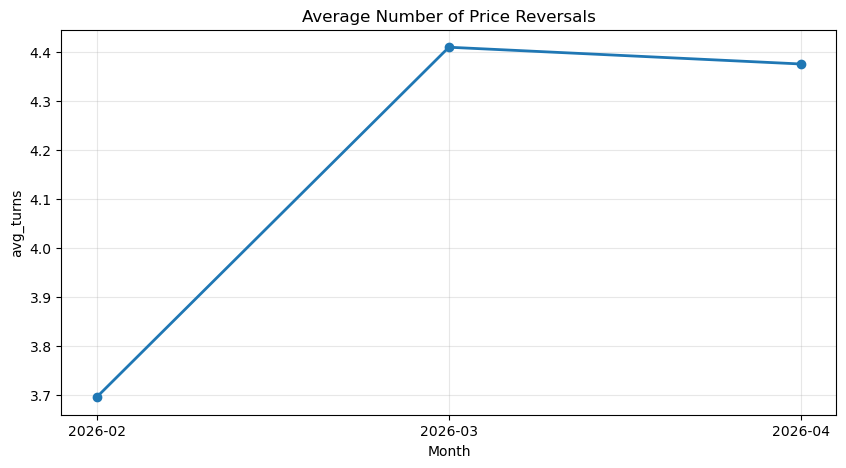

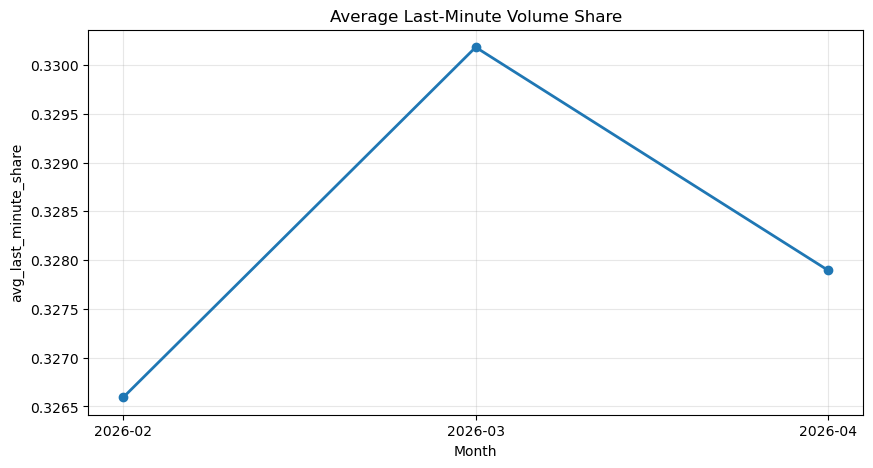

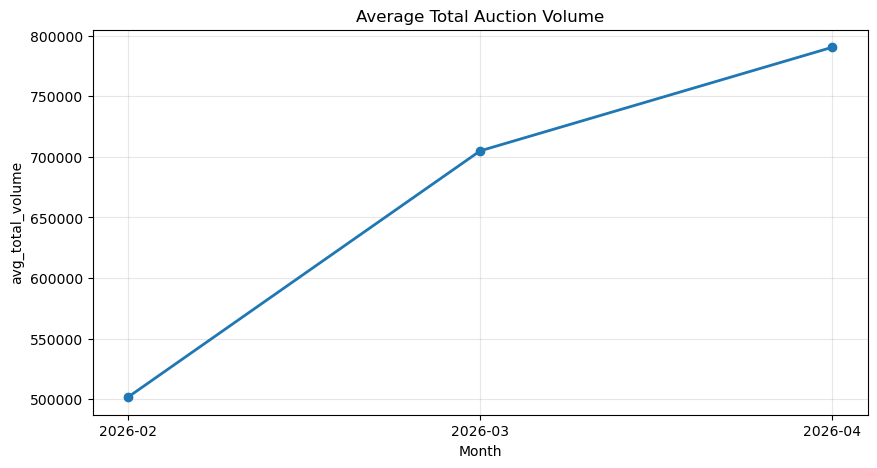

In [54]:
monthly_metrics = {
    "avg_abs_return": "Average Absolute Auction Return",
    "avg_range_pct": "Average Auction Price Range",
    "avg_volatility": "Average Auction Volatility",
    "avg_turns": "Average Number of Price Reversals",
    "avg_last_minute_share": "Average Last-Minute Volume Share",
    "avg_total_volume": "Average Total Auction Volume"
}

for metric, title in monthly_metrics.items():
    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_summary["month"],
        monthly_summary[metric],
        marker="o",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.show()

##### Figure 1. Average Absolute Auction Return
三个月内，平均绝对收益率（Average Absolute Auction Return）整体保持稳定，仅在 3 月略有上升，4 月略有回落，整体波动幅度较小。

尽管不同月份市场成交活跃程度有所变化，但集合竞价最终形成的价格偏离幅度并未出现明显变化。

这一结果说明，集合竞价最终形成的开盘价格具有较好的稳定性。

随着市场交易活跃程度提升，价格发现过程可能更加复杂，但最终形成的均衡价格并不会因此产生更大的偏离。

因此，Auction Return 更像是价格发现结果（Outcome），而不是价格发现过程（Process）的体现。

##### Figure 2. Average Auction Price Range
平均价格波动区间（Price Range）呈现持续上升趋势：

2 月约为 2.35%
3 月约为 2.78%
4 月约为 2.86%

说明价格探索范围逐渐扩大。

价格波动区间反映的是集合竞价期间市场寻找均衡价格所经历的调整范围。随着时间推移，市场参与度不断提高，买卖双方报价更加积极，使得虚拟成交价格经历了更大的上下调整。

因此，可以认为：市场越活跃，价格发现过程越充分，均衡价格需要经历更大的搜索空间才能形成。
Price Range 可以作为衡量 Auction Uncertainty（集合竞价不确定性）的重要指标。

##### Figure 3. Average Auction Volatility
Auction Volatility 在三个月内持续上升，与 Price Range 呈现一致趋势。

说明集合竞价期间价格变化越来越频繁，短时间内价格波动幅度有所增加。

Volatility 描述的是价格变化速度，而 Price Range 描述的是价格探索空间。

二者同步增加说明：

价格不仅探索范围更大，而且探索过程更加活跃。因此，随着市场成交更加活跃，价格发现过程逐渐由相对平稳演变为更加动态的调整过程。

##### Figure 4. Average Number of Price Reversals
Observation

平均价格反转次数（Price Reversals）由 2 月约 3.7 次 上升至 3 月 4.4 次，4 月保持在相近水平。

说明价格方向变化更加频繁。

Analysis

价格反转次数衡量的是价格形成过程中方向切换的频率，而不是价格波动大小。

反转次数增加意味着：

买卖双方对于合理价格存在更大分歧；
新进入订单不断修正市场预期；
价格形成过程更加复杂。

相比传统波动率，Price Reversal 更能够体现集合竞价中的市场博弈程度（Market Interaction）。

##### Figure 5. Average Last-Minute Volume Share
Observation

三个月中，最后一分钟成交占比始终保持在 约 33% 左右，几乎没有明显变化。

即使整体成交量增加，该比例依然十分稳定。

Analysis

这一结果说明：

最后一分钟成交集中现象并非由市场环境决定，而更可能来源于集合竞价机制本身。

随着集合竞价接近结束，市场能够观察到更加稳定的虚拟成交价格，因此大量投资者倾向于在最后阶段提交委托。

因此：

Last-Minute Volume Share 更像是一种制度特征（Structural Characteristic），而不是市场情绪特征。

##### Figure 6. Average Total Auction Volume
Observation

平均成交量呈持续增长趋势：

2 月约 50 万股
3 月约 70 万股
4 月约 79 万股

说明市场交易活跃程度不断提高。

Analysis

成交量增加意味着更多投资者参与集合竞价。

与此同时：

Price Range 上升；
Volatility 上升；
Price Reversal 上升。

说明成交量增加不仅带来了更多交易，也使价格发现过程更加充分。

因此，本研究初步认为：

更高的市场流动性对应更加活跃的价格发现过程。

### 3.3.2 Board Comparison

In [55]:
qtick_long = qtick_long.drop(
    columns=["board", "board_x", "board_y"],
    errors="ignore"
)

# Merge clean board info from stock_pool_15
qtick_long = qtick_long.merge(
    stock_pool_15[["code", "board"]],
    on="code",
    how="left"
)

print(qtick_long["board"].value_counts(dropna=False))
display(qtick_long[["code", "board"]].drop_duplicates().sort_values("code"))

board
main       2533733
chinext    1068474
Name: count, dtype: int64


,code,board
31518,000010.SZ,main
10726,000155.SZ,main
26912,000950.SZ,main
53128,001288.SZ,main
35459,002015.SZ,main
0,002292.SZ,main
40151,002655.SZ,main
15528,002708.SZ,main
4816,002713.SZ,main
19961,002777.SZ,main


In [56]:
feature_long = build_auction_features(qtick_long)

print(feature_long["board"].value_counts(dropna=False))
display(feature_long.head())

board
main       569
chinext    285
Name: count, dtype: int64


,code,date,month,board,first_price,last_price,max_price,min_price,auction_return,up_move,...,price_range_pct,price_volatility,n_price_changes,n_turns,total_volume,last_minute_volume,last_minute_volume_share,volume_weighted_price,n_ticks,trend_label
0,000010.SZ,2026-02-02,2026-02,main,3.39,3.405,3.420,3.39,0.004425,0.008850,...,0.008850,0.002343,3,1.0,97100,11200,0.115345,3.405000,18,up_smooth
1,000010.SZ,2026-02-03,2026-02,main,3.40,3.415,3.420,3.40,0.004412,0.005882,...,0.005882,0.001409,2,1.0,92900,1700,0.018299,3.415000,20,up_smooth
2,000010.SZ,2026-02-04,2026-02,main,3.51,3.525,3.525,3.46,0.004274,0.004274,...,0.018519,0.003629,7,2.0,321000,23300,0.072586,3.525000,24,up_with_reversal
3,000010.SZ,2026-02-05,2026-02,main,3.58,3.575,3.580,3.57,-0.001397,0.000000,...,0.002793,0.000777,2,1.0,47900,19000,0.396660,3.571983,18,down_smooth
4,000010.SZ,2026-02-06,2026-02,main,3.73,3.770,3.785,3.71,0.010724,0.014745,...,0.020107,0.002951,8,5.0,1176000,496000,0.421769,3.778673,46,up_volatile


In [57]:
monthly_board_summary = (
    feature_long
    .groupby(["month", "board"])
    .agg(
        n_stock_days=("code", "count"),
        n_stocks=("code", "nunique"),
        n_days=("date", "nunique"),

        avg_abs_return=("auction_return", lambda x: x.abs().mean()),
        avg_range_pct=("price_range_pct", "mean"),
        avg_volatility=("price_volatility", "mean"),
        avg_turns=("n_turns", "mean"),
        avg_last_minute_share=("last_minute_volume_share", "mean"),
        avg_total_volume=("total_volume", "mean")
    )
    .reset_index()
)

display(monthly_board_summary)

,month,board,n_stock_days,n_stocks,n_days,avg_abs_return,avg_range_pct,avg_volatility,avg_turns,avg_last_minute_share,avg_total_volume
0,2026-02,chinext,70,5,14,0.012393,0.016440,0.002872,3.771429,0.441255,169553.114286
1,2026-02,main,140,10,14,0.018302,0.027057,0.003132,3.657143,0.269264,667748.600000
2,2026-03,chinext,110,5,22,0.010456,0.020241,0.003646,4.240741,0.421171,211232.100000
3,2026-03,main,220,10,22,0.020571,0.031627,0.003890,4.493088,0.284689,951877.363636
4,2026-04,chinext,105,5,21,0.015425,0.027255,0.004828,4.349515,0.434638,487363.504762
5,2026-04,main,209,10,21,0.017759,0.029223,0.003700,4.387560,0.274781,942822.933014


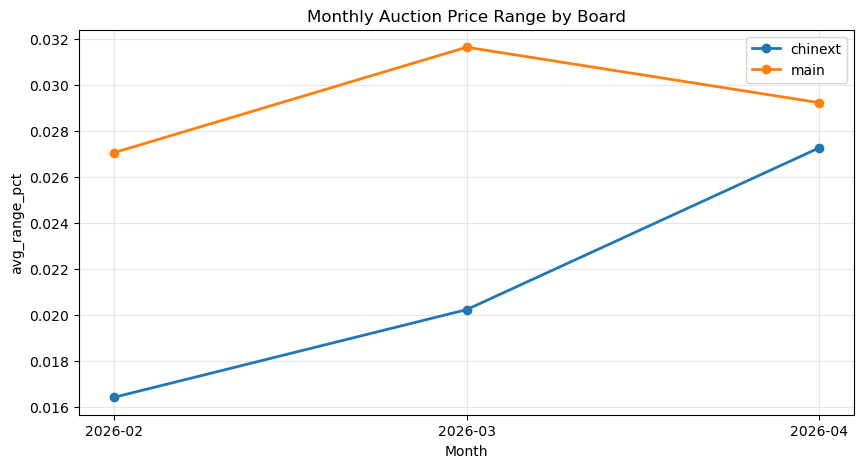

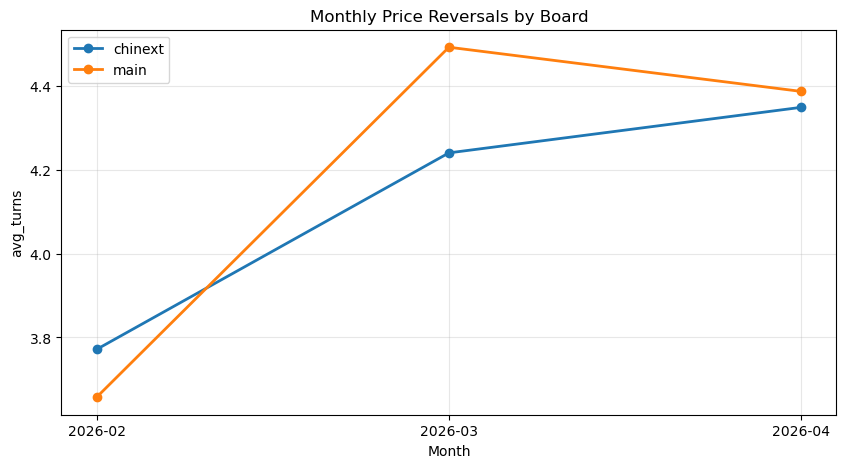

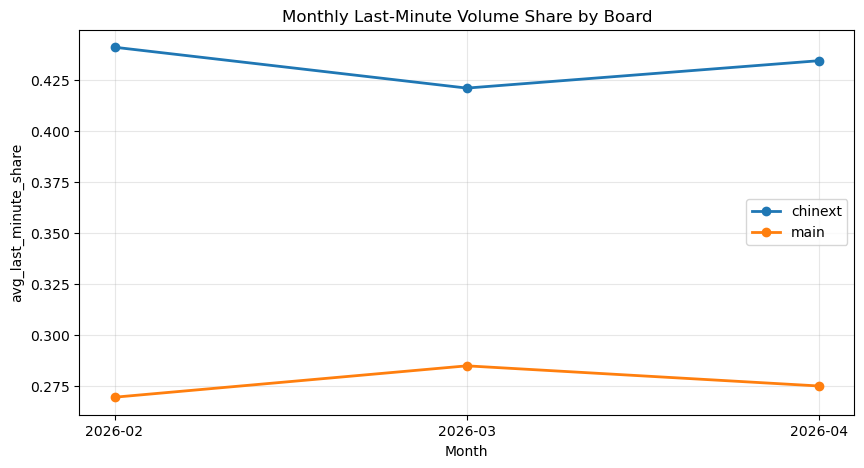

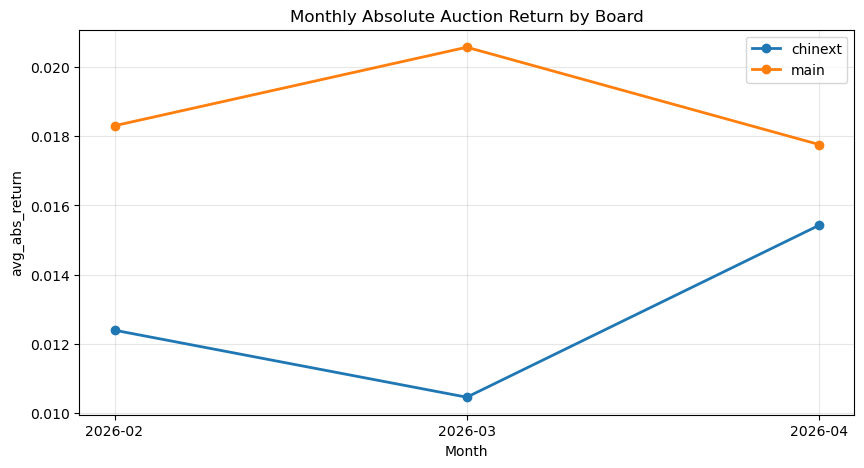

In [59]:
board_metrics = {
    "avg_range_pct": "Monthly Auction Price Range by Board",
    "avg_turns": "Monthly Price Reversals by Board",
    "avg_last_minute_share": "Monthly Last-Minute Volume Share by Board",
    "avg_abs_return": "Monthly Absolute Auction Return by Board"
}

for metric, title in board_metrics.items():
    plt.figure(figsize=(10, 5))

    for board in monthly_board_summary["board"].dropna().unique():
        temp = monthly_board_summary[
            monthly_board_summary["board"] == board
        ].sort_values("month")

        plt.plot(
            temp["month"],
            temp[metric],
            marker="o",
            linewidth=2,
            label=board
        )

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

在本样本中，
##### Figure 7. Monthly Auction Price Range by Board
主板股票在三个月内始终表现出更大的价格波动区间，但创业板 Price Range 增长速度更快，两者之间的差距逐渐缩小。

主板股票整体价格发现空间较大，说明其集合竞价期间价格调整更加充分。然而，创业板在市场活跃时期价格波动区间增长更快，表明成长型股票对于市场环境变化具有更高敏感性。

##### Figure 8. Monthly Price Reversals by Board
两类股票价格反转次数均随时间增加。主板整体略高于创业板，但两者逐渐趋于接近。

这一结果说明：
无论板块如何，随着市场活跃程度提升，价格形成路径都会变得更加复杂。
创业板价格发现复杂度提升速度更快，而主板则始终保持较高水平。

##### Figure 9. Monthly Last-Minute Volume Share by Board
创业板最后一分钟成交占比始终维持在 约 42%，明显高于主板约 27%。
两者在三个月内均保持稳定。

说明：创业板投资者更倾向于等待更多市场信息，在集合竞价最后阶段集中提交订单。相比之下，主板投资者委托时间分布更加均匀。

因此：
创业板具有更明显的“最后一分钟交易”特征，体现出更强的信息等待行为。

##### Figure 10. Monthly Absolute Auction Return by Board
主板股票平均绝对收益率整体高于创业板。创业板在 4 月有所上升，但整体仍低于主板。

说明主板股票最终形成的开盘价格偏离程度略高。然而，两类股票变化趋势整体较为平稳，并未随着市场活跃程度增加而出现明显扩大。因此，最终价格结果相对稳定，而真正发生变化的是价格发现过程本身。

这说明,
1. 集合竞价最终形成的价格结果相对稳定。
无论市场活跃程度如何变化，Auction Return 并未出现明显变化，说明集合竞价能够较稳定地形成均衡开盘价。
2. 价格发现过程随着市场活跃度提升而更加复杂。
Price Range、Volatility、Price Reversal 以及 Total Volume 均呈现上升趋势，说明价格发现过程更加充分，市场参与者之间的博弈更加激烈。
3. 最后一分钟成交集中度具有明显制度特征。
Last-Minute Volume Share 在不同月份保持稳定，表明成交时间分布主要由集合竞价规则决定，而非市场情绪驱动。
4. 创业板与主板表现出不同的市场微观结构特征。
创业板具有更高的最后一分钟成交占比，说明投资者更加倾向于延迟决策；而主板整体价格波动区间更大，但创业板对市场环境变化的响应速度更快。

4 Feature Validation
    4.1 Distribution Validation
    4.2 Correlation Analysis
    4.3 Board Comparison
    4.4 Statistical Tests
    4.5 Relationship with Prediction Target
    4.6 Feature Importance

5 Opening Price Prediction
    5.1 Target Construction
    5.2 Train/Test Split
    5.3 Baseline Model
    5.4 Model Evaluation
    5.5 Feature Importance

6 Conclusion & Future Work